In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 130,
})

C = {
    "blue": "#185FA5", "green": "#0F6E56", "orange": "#E85D24",
    "gold": "#BA7517", "purple": "#534AB7", "red": "#A32D2D", "gray": "#73726c",
}
ASSET_C = {
    "BIST100": "#185FA5", "Gold_USD": "#BA7517",
    "Brent":   "#A32D2D", "USD_TRY":  "#E85D24", "EUR_TRY": "#73726c",
}

START, END   = "2013-01-01", "2026-03-01"
EVDS_KEY     = "JlKUjsBKDY"
RF_ANNUAL    = 0.45
RF_MONTHLY   = RF_ANNUAL / 12
PERIODS      = 12
ASSETS       = ["BIST100", "Gold_USD", "Brent", "USD_TRY", "EUR_TRY"]
HORIZON_3Y   = 36
HORIZON_5Y   = 60

Path("cache").mkdir(exist_ok=True)

def cache_read(name):
    p = Path(f"cache/{name}.csv")
    if p.exists() and p.stat().st_size > 500:
        df = pd.read_csv(p, index_col=0, parse_dates=True)
        return df if not df.empty else None
    return None

def cache_write(df, name):
    df.to_csv(Path(f"cache/{name}.csv"))

print(f"Setup complete | Period: {START} to {END} | Rf: {RF_ANNUAL*100:.0f}% annual")

Setup complete | Period: 2013-01-01 to 2026-03-01 | Rf: 45% annual


In [2]:
import yfinance as yf

YAHOO_TICKERS = {
    "BIST100": "XU100.IS", "Gold_USD": "GC=F",
    "Brent":   "BZ=F",     "USD_TRY":  "TRY=X", "EUR_TRY": "EURTRY=X",
}

yahoo_df = cache_read("yahoo")
if yahoo_df is None:
    raw = yf.download(
        list(YAHOO_TICKERS.values()), start=START, end=END,
        interval="1mo", auto_adjust=True, progress=False,
    )
    yahoo_df = raw["Close"].copy()
    yahoo_df.columns = list(YAHOO_TICKERS.keys())
    yahoo_df.index   = pd.to_datetime(yahoo_df.index).to_period("M").to_timestamp()
    yahoo_df = yahoo_df.dropna(how="all").sort_index()
    cache_write(yahoo_df, "yahoo")

print(f"Yahoo ready: {len(yahoo_df)} obs | {yahoo_df.index[0].date()} to {yahoo_df.index[-1].date()}")
print(yahoo_df.tail(3).round(2))

Yahoo ready: 158 obs | 2013-01-01 to 2026-02-01
            BIST100  Gold_USD   Brent  USD_TRY  EUR_TRY
Date                                                   
2025-12-01    60.85     50.60  4325.6    42.95  11261.5
2026-01-01    70.69     51.94  4713.9    43.46  13838.3
2026-02-01      NaN     51.91     NaN    43.96  13717.8


In [3]:
pip install evds

In [4]:
from evds import evdsAPI

EVDS_SERIES = {
    "TP.FE.OKTG01":    ("CPI_yoy_pct",    3),
    "TP.DK.USD.S.YTL": ("USD_TRY_tcmb",   0),
    "TP.DK.EUR.S.YTL": ("EUR_TRY_tcmb",   0),
    "TP.TRF.TRL.A01":  ("policy_rate_pct", 0),
}

def parse_evds_date(series):
    def fix(d):
        p = str(d).split("-")
        return f"{p[0]}-{int(p[1]):02d}"
    return pd.to_datetime(series.apply(fix), format="%Y-%m")

def fetch_one(api, code, col_name, formulas, bas, bit):
    raw     = api.get_data([code], startdate=bas, enddate=bit, frequency=5, formulas=formulas)
    val_col = [c for c in raw.columns if c != "Tarih"][0]
    s       = raw[["Tarih", val_col]].rename(columns={val_col: col_name})
    s["Tarih"] = parse_evds_date(s["Tarih"])
    s = s.set_index("Tarih").sort_index()
    s[col_name] = pd.to_numeric(s[col_name].astype(str).str.replace(",", "."), errors="coerce")
    s.index = s.index.to_period("M").to_timestamp()
    return s[col_name]

broken = Path("cache/evds.csv")
if broken.exists() and pd.read_csv(broken, index_col=0).shape[1] < len(EVDS_SERIES):
    broken.unlink()

evds_df = cache_read("evds")
if evds_df is None:
    api = evdsAPI(EVDS_KEY)
    bas = pd.Timestamp(START).strftime("%d-%m-%Y")
    bit = pd.Timestamp(END).strftime("%d-%m-%Y")
    frames = {}
    for code, (col, fmt) in EVDS_SERIES.items():
        try:
            frames[col] = fetch_one(api, code, col, fmt, bas, bit)
        except Exception as e:
            print(f"  Warning: {col} fetch failed — {e}")
    evds_df = pd.DataFrame(frames).sort_index()
    cache_write(evds_df, "evds")

print(f"EVDS ready: {len(evds_df)} obs | {evds_df.index[0].date()} to {evds_df.index[-1].date()}")
print(evds_df.tail(4).round(2))

EVDS ready: 159 obs | 2013-01-01 to 2026-03-01
            CPI_yoy_pct  USD_TRY_tcmb  EUR_TRY_tcmb
Tarih                                              
2025-12-01        30.89         42.66         49.94
2026-01-01          NaN         43.19         50.65
2026-02-01          NaN         43.66         51.68
2026-03-01          NaN         44.14         51.11


Master dataset: (156, 7) | 2013-01-01 to 2025-12-01


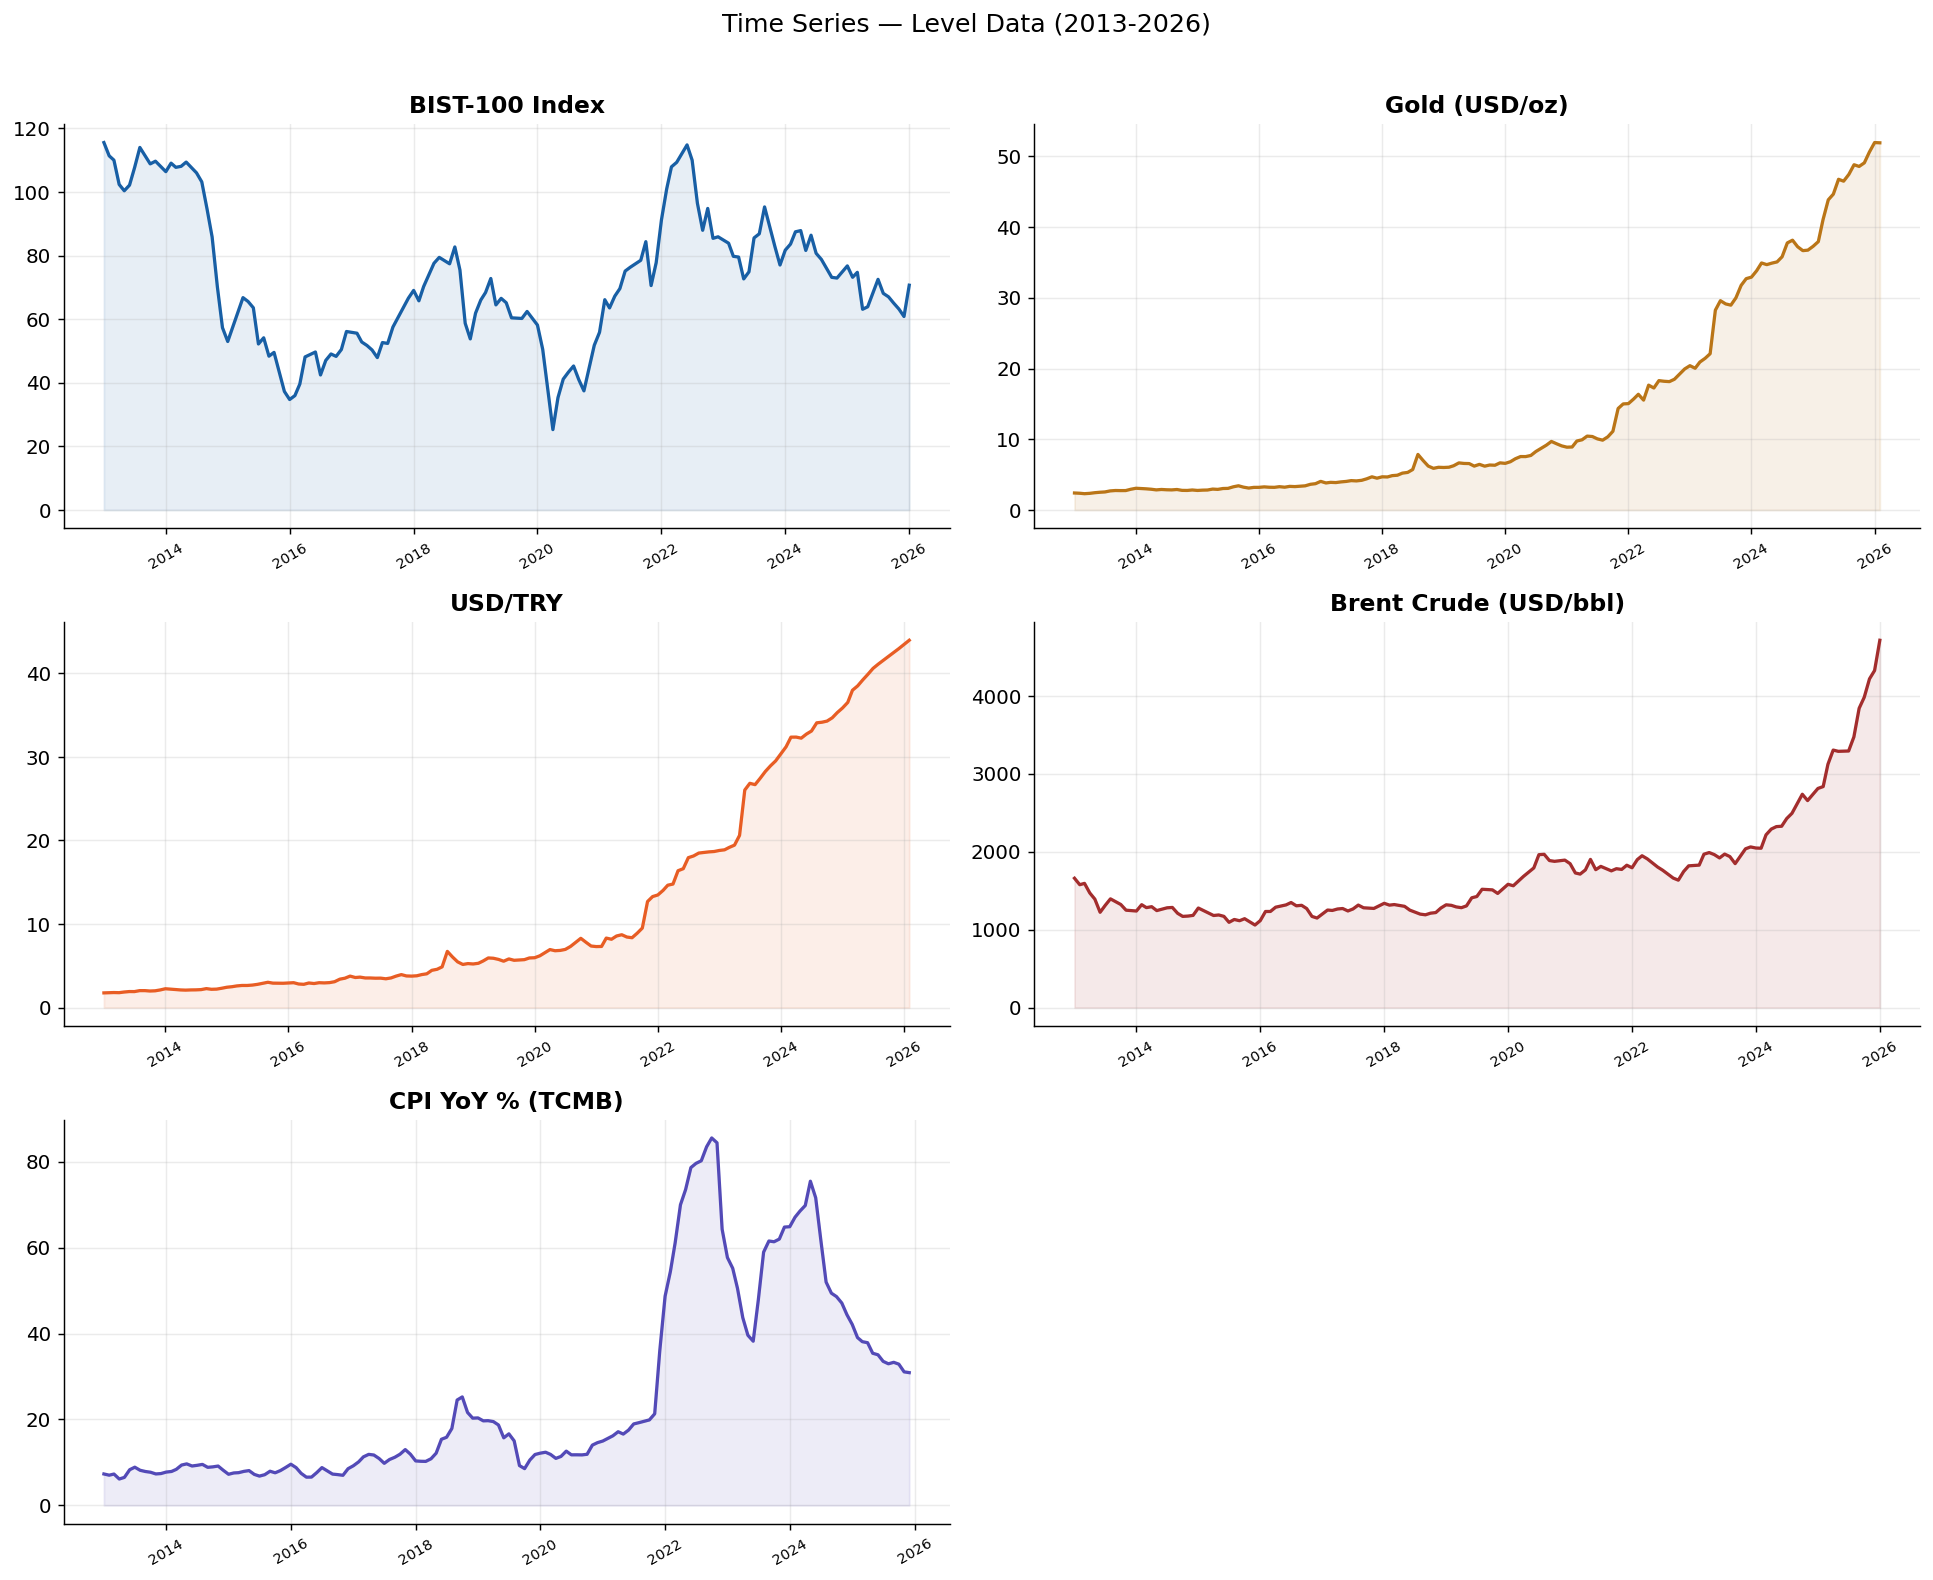

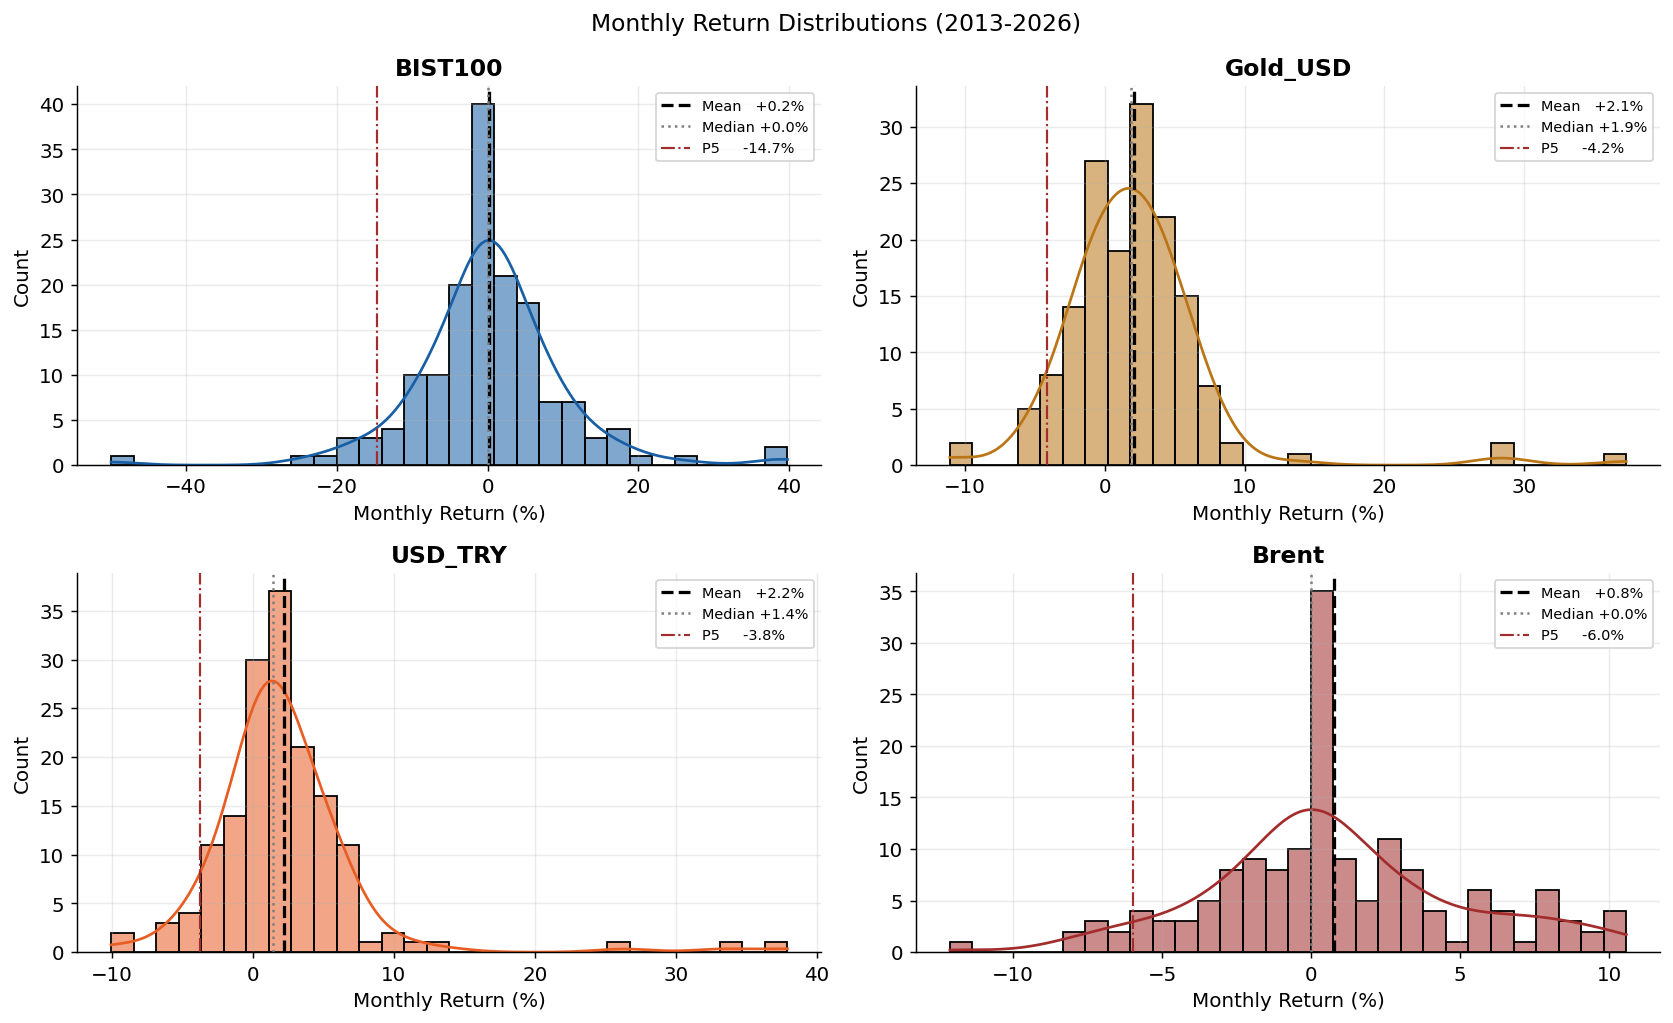

In [5]:
evds_cols = [c for c in ["CPI_yoy_pct", "USD_TRY_tcmb", "policy_rate_pct"] if c in evds_df.columns]
master_df = (
    yahoo_df.join(evds_df[evds_cols], how="inner")
    .sort_index()
    .dropna(subset=["USD_TRY", "CPI_yoy_pct"])
)
cache_write(master_df, "master")
print(f"Master dataset: {master_df.shape} | {master_df.index[0].date()} to {master_df.index[-1].date()}")

PANELS = [
    (yahoo_df, "BIST100",   "BIST-100 Index",        C["blue"]),
    (yahoo_df, "Gold_USD",  "Gold (USD/oz)",          C["gold"]),
    (yahoo_df, "USD_TRY",   "USD/TRY",               C["orange"]),
    (yahoo_df, "Brent",     "Brent Crude (USD/bbl)", C["red"]),
    (evds_df,  "CPI_yoy_pct",    "CPI YoY % (TCMB)", C["purple"]),
]
if "policy_rate_pct" in evds_df.columns:
    PANELS.append((evds_df, "policy_rate_pct", "Policy Rate % (TCMB)", C["green"]))

n_rows = (len(PANELS) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4 * n_rows))
fig.suptitle("Time Series — Level Data (2013-2026)", fontsize=14, y=1.01)
for ax, (df, col, title, color) in zip(axes.flatten(), PANELS):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, lw=1.8)
    ax.fill_between(s.index, s.values, alpha=0.10, color=color)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
for ax in axes.flatten()[len(PANELS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("cache/eda_levels.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Monthly Return Distributions (2013-2026)", fontsize=13)
for ax, col in zip(axes.flatten(), ["BIST100", "Gold_USD", "USD_TRY", "Brent"]):
    s = yahoo_df[col].pct_change().dropna() * 100
    sns.histplot(s, ax=ax, color=ASSET_C[col], alpha=0.55, kde=True, bins=30)
    ax.axvline(s.mean(),         color="black",  lw=1.8, ls="--", label=f"Mean   {s.mean():+.1f}%")
    ax.axvline(s.median(),       color="gray",   lw=1.4, ls=":",  label=f"Median {s.median():+.1f}%")
    ax.axvline(s.quantile(0.05), color=C["red"], lw=1.2, ls="-.", label=f"P5     {s.quantile(0.05):+.1f}%")
    ax.set_title(col)
    ax.set_xlabel("Monthly Return (%)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("cache/eda_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

if "policy_rate_pct" in master_df.columns:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(master_df.index, master_df["CPI_yoy_pct"],    color=C["red"],    lw=1.8, label="CPI YoY %")
    ax.plot(master_df.index, master_df["policy_rate_pct"], color=C["green"],  lw=1.8, ls="--", label="Policy Rate %")
    ax2 = ax.twinx()
    ax2.plot(master_df.index, master_df["USD_TRY"], color=C["orange"], lw=1.2, alpha=0.6, label="USD/TRY (right)")
    ax2.set_ylabel("USD/TRY", color=C["orange"])
    ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.4)
    ax.set_title("CPI, Policy Rate & USD/TRY (2013-2026)")
    ax.set_ylabel("%")
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9)
    plt.tight_layout()
    plt.savefig("cache/macro_overview.png", dpi=130, bbox_inches="tight")
    plt.show()

In [7]:
print("MASTER DATASET OVERVIEW")
print(f"Shape: {master_df.shape[0]} rows x {master_df.shape[1]} cols")
print(f"Period: {master_df.index[0].date()} to {master_df.index[-1].date()}\n")

info = pd.DataFrame({
    "dtype":       master_df.dtypes,
    "non_null":    master_df.notna().sum(),
    "nan_count":   master_df.isna().sum(),
    "nan_pct":     (master_df.isna().mean() * 100).round(2),
    "first_valid": [master_df[c].first_valid_index() for c in master_df.columns],
    "last_valid":  [master_df[c].last_valid_index()  for c in master_df.columns],
})
print(info.to_string())

print("\nDESCRIPTIVE STATISTICS")
stats = master_df.describe().T
stats["skew"] = master_df.skew().round(3)
stats["kurt"] = master_df.kurt().round(3)
print(stats.round(3).to_string())

print("\nNaN HANDLING POLICY")
nan_cols = info[info["nan_count"] > 0]
if nan_cols.empty:
    print("No NaN values in master dataset after join + dropna(subset=['USD_TRY','CPI_yoy_pct']).")
else:
    for col, row in nan_cols.iterrows():
        print(f"  {col:<20} {int(row['nan_count'])} NaN ({row['nan_pct']}%)")

MASTER DATASET OVERVIEW
Shape: 156 rows x 7 cols
Period: 2013-01-01 to 2025-12-01

                dtype  non_null  nan_count  nan_pct first_valid last_valid
BIST100       float64       134         22     14.1  2013-01-01 2025-12-01
Gold_USD      float64       156          0      0.0  2013-01-01 2025-12-01
Brent         float64       134         22     14.1  2013-01-01 2025-12-01
USD_TRY       float64       156          0      0.0  2013-01-01 2025-12-01
EUR_TRY       float64       156          0      0.0  2013-01-01 2025-12-01
CPI_yoy_pct   float64       156          0      0.0  2013-01-01 2025-12-01
USD_TRY_tcmb  float64       156          0      0.0  2013-01-01 2025-12-01

DESCRIPTIVE STATISTICS
              count      mean       std       min       25%       50%       75%        max   skew   kurt
BIST100       134.0    72.555    21.394    25.270    55.943    70.210    85.785    115.550  0.257 -0.686
Gold_USD      156.0    13.200    13.650     2.301     3.270     6.504    18.335    

Risk-Return Metrics (Rf ~45% annual)
          Ann_Return_%  Ann_Vol_%  Sharpe  Sortino   MDD_%  Calmar
BIST100          1.325     34.537  -1.265   -1.722 -77.835   0.017
Gold_USD        28.673     19.177  -1.018   -2.024 -25.054   1.144
Brent            8.793     14.422  -2.534   -3.692 -33.515   0.262
USD_TRY         30.066     19.211  -0.959   -2.089 -23.224   1.295
EUR_TRY         26.908     26.298  -0.796   -1.432 -28.110   0.957


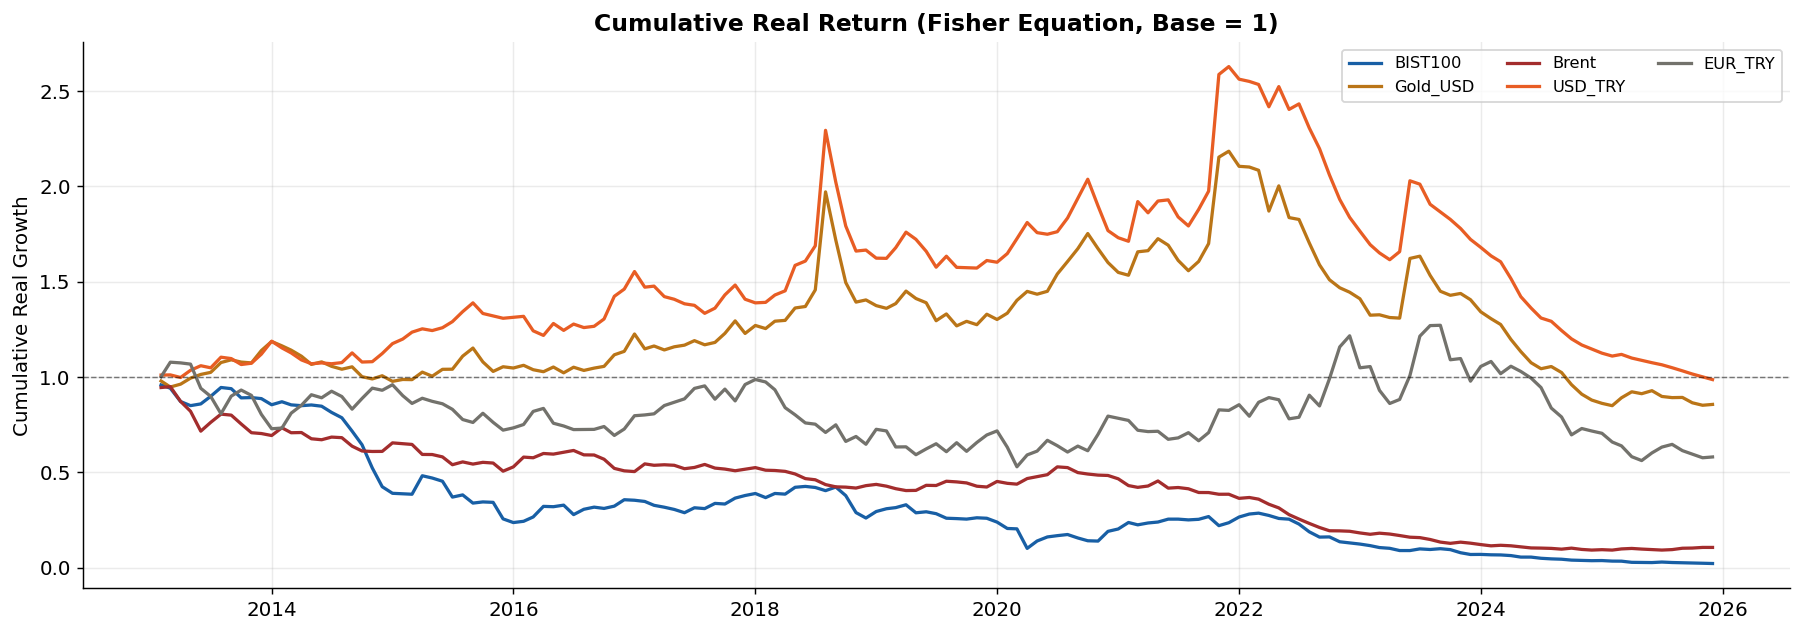

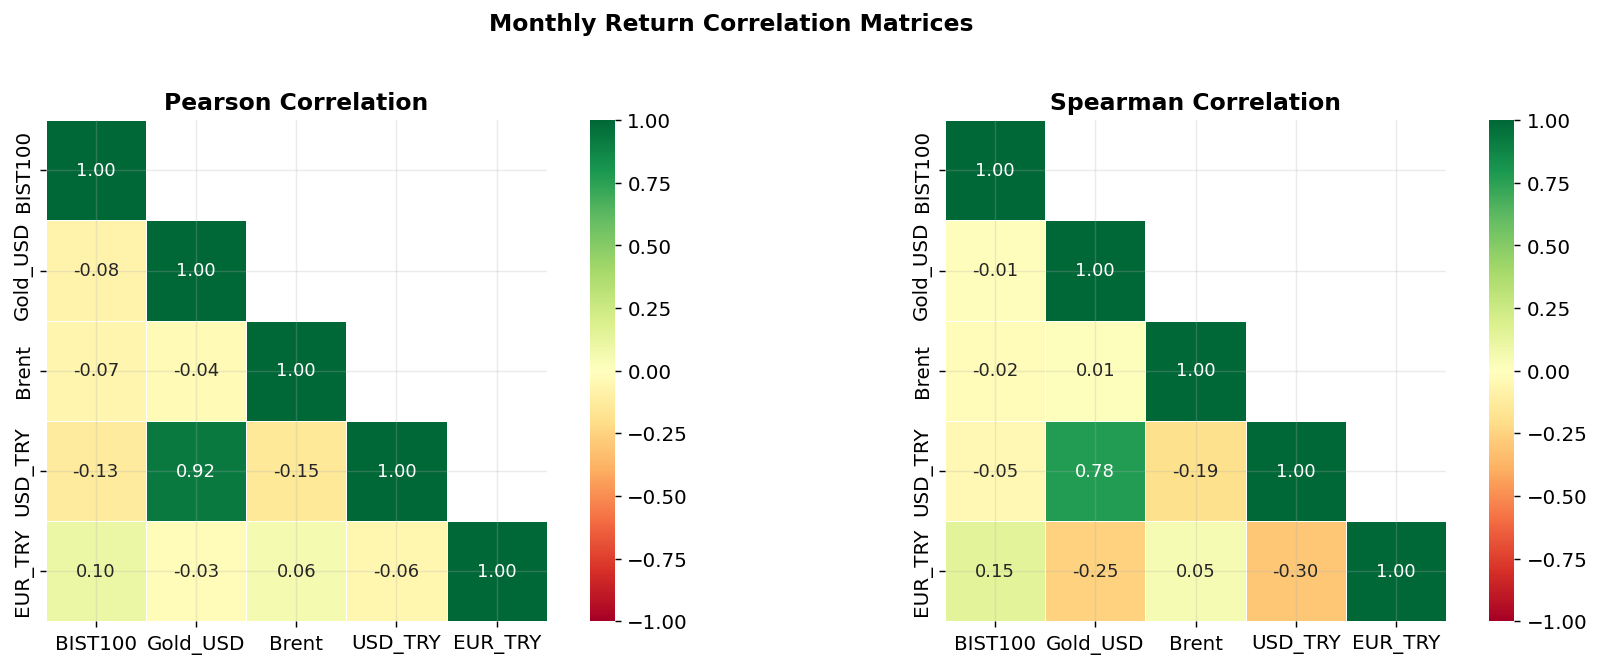

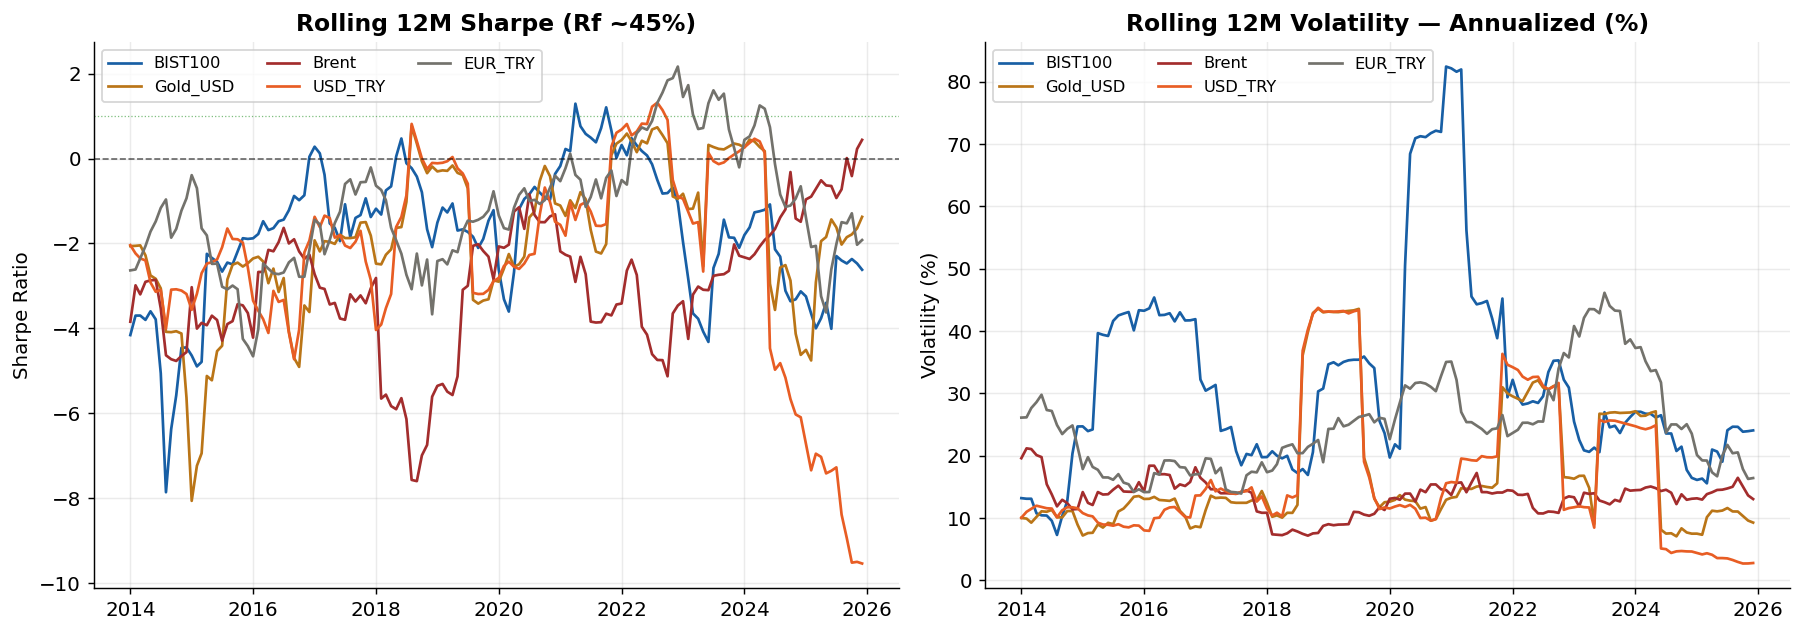

In [8]:
arith_ret = master_df[ASSETS].pct_change().dropna()

monthly_cpi = master_df.loc[arith_ret.index, "CPI_yoy_pct"] / 100 / 12
real_ret    = (1 + arith_ret).div(1 + monthly_cpi, axis=0) - 1
cumreal     = (1 + real_ret[ASSETS]).cumprod()

def sharpe(s):
    ex = s - RF_MONTHLY
    return (ex.mean() / ex.std()) * np.sqrt(PERIODS)

def sortino(s):
    ex  = s - RF_MONTHLY
    dsd = ex[ex < 0].std()
    return (ex.mean() / dsd) * np.sqrt(PERIODS) if dsd > 0 else np.nan

def max_drawdown(s):
    cum = (1 + s).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

def calmar(s):
    ann = (1 + s.mean()) ** PERIODS - 1
    mdd = max_drawdown(s)
    return ann / abs(mdd) if mdd != 0 else np.nan

metrics = pd.DataFrame({
    "Ann_Return_%": {c: ((1 + arith_ret[c].mean())**PERIODS - 1) * 100 for c in ASSETS},
    "Ann_Vol_%":    {c: arith_ret[c].std() * np.sqrt(PERIODS) * 100    for c in ASSETS},
    "Sharpe":       {c: sharpe(arith_ret[c])                           for c in ASSETS},
    "Sortino":      {c: sortino(arith_ret[c])                          for c in ASSETS},
    "MDD_%":        {c: max_drawdown(arith_ret[c]) * 100               for c in ASSETS},
    "Calmar":       {c: calmar(arith_ret[c])                           for c in ASSETS},
})

pearson_corr  = arith_ret.corr(method="pearson")
spearman_corr = arith_ret.corr(method="spearman")
WINDOW        = 12
rolling_vol    = arith_ret.rolling(WINDOW).std() * np.sqrt(PERIODS) * 100
rolling_sharpe = (
    (arith_ret - RF_MONTHLY).rolling(WINDOW)
    .apply(lambda x: (x.mean() / x.std()) * np.sqrt(PERIODS) if x.std() > 0 else np.nan, raw=True)
)

print(f"Risk-Return Metrics (Rf ~{RF_ANNUAL*100:.0f}% annual)")
print(metrics.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
for col in ASSETS:
    ax.plot(cumreal.index, cumreal[col], label=col, lw=1.8, color=ASSET_C[col])
ax.axhline(1, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_title("Cumulative Real Return (Fisher Equation, Base = 1)")
ax.set_ylabel("Cumulative Real Growth")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("cache/cumreal_return.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, corr) in zip(axes, [("Pearson", pearson_corr), ("Spearman", spearman_corr)]):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, mask=mask, square=True,
                linewidths=0.5, annot_kws={"size": 10})
    ax.set_title(f"{title} Correlation")
fig.suptitle("Monthly Return Correlation Matrices", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cache/correlation.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col in ASSETS:
    axes[0].plot(rolling_sharpe.index, rolling_sharpe[col], label=col, lw=1.5, color=ASSET_C[col])
    axes[1].plot(rolling_vol.index,    rolling_vol[col],    label=col, lw=1.5, color=ASSET_C[col])
axes[0].axhline(0, lw=0.9, color="black", ls="--", alpha=0.6)
axes[0].axhline(1, lw=0.7, color="green", ls=":", alpha=0.5)
axes[0].set_title(f"Rolling 12M Sharpe (Rf ~{RF_ANNUAL*100:.0f}%)")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].legend(ncol=3, fontsize=9)
axes[1].set_title("Rolling 12M Volatility — Annualized (%)")
axes[1].set_ylabel("Volatility (%)")
axes[1].legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("cache/rolling_metrics.png", dpi=130, bbox_inches="tight")
plt.show()

Crisis months: 49 (31.6%)  |  Normal: 106

Crisis vs. Normal Comparison
         Normal                      Crisis                     
          Mean%   Vol%  Hit% Median%  Mean%   Vol%  Hit% Median%
BIST100    0.89  29.06  43.4    0.00  -1.57  43.92  42.9    0.00
Gold_USD   1.36  11.08  61.3    1.47   3.77  29.37  75.5    3.05
Brent      1.10  14.28  52.8    0.23  -0.14  14.43  38.8    0.00
USD_TRY    1.47  11.34  70.8    1.22   3.83  29.25  79.6    1.91
EUR_TRY    1.90  21.91  60.4    1.71   2.23  34.18  51.0    0.28

Welch t-test (H0: no return difference between crisis and normal)
  BIST100       t=+1.236  p=0.221  ns
  Gold_USD      t=-1.929  p=0.059  *
  Brent         t=+1.729  p=0.087  *
  USD_TRY       t=-1.895  p=0.063  *
  EUR_TRY       t=-0.209  p=0.835  ns


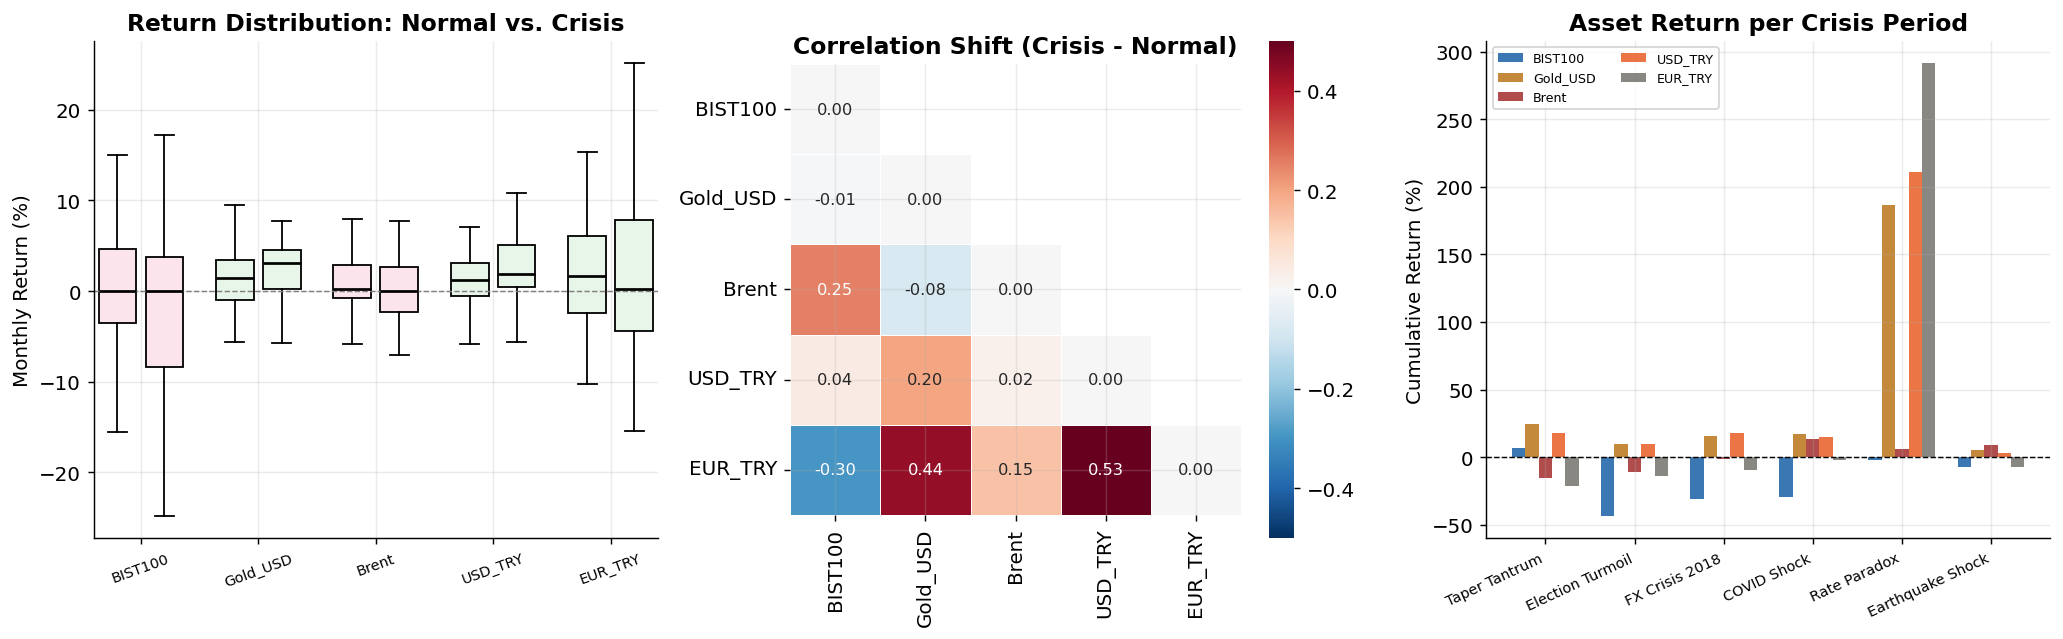

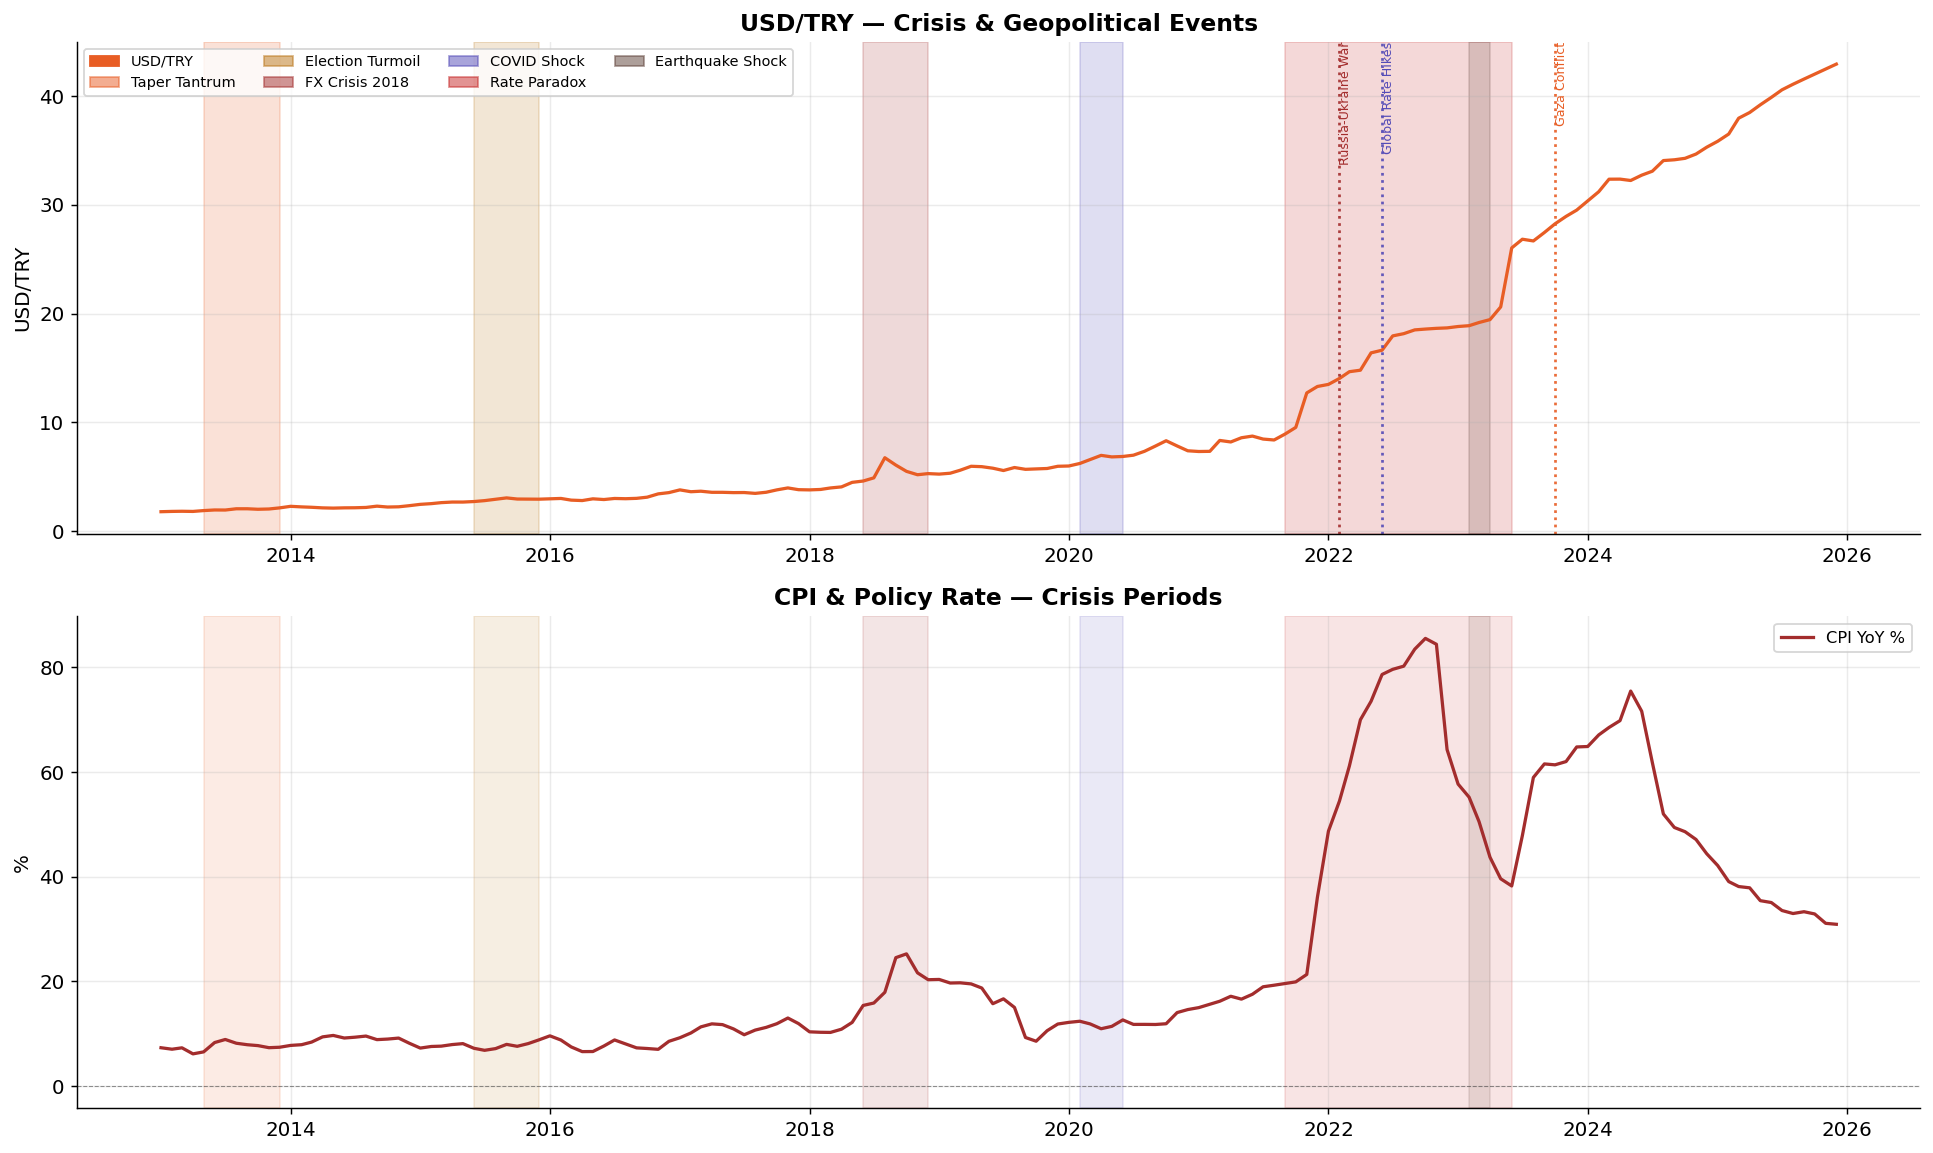

In [9]:
CRISIS_PERIODS = [
    ("Taper Tantrum",      "2013-05", "2013-12", "#E85D24"),
    ("Election Turmoil",   "2015-06", "2015-12", "#BA7517"),
    ("FX Crisis 2018",     "2018-06", "2018-12", "#A32D2D"),
    ("COVID Shock",        "2020-02", "2020-06", "#534AB7"),
    ("Rate Paradox",       "2021-09", "2023-06", "#C62828"),
    ("Earthquake Shock",   "2023-02", "2023-04", "#5D4037"),
]

GEOPOLITICAL_EVENTS = [
    ("Russia-Ukraine War",   "2022-02", C["red"]),
    ("Gaza Conflict",        "2023-10", C["orange"]),
    ("Global Rate Hikes",    "2022-06", C["purple"]),
]

crisis_flag  = pd.Series(False,    index=arith_ret.index, name="is_crisis")
crisis_label = pd.Series("Normal", index=arith_ret.index, name="period")
for name, start, end, _ in CRISIS_PERIODS:
    mask = (arith_ret.index >= start) & (arith_ret.index <= end)
    crisis_flag[mask]  = True
    crisis_label[mask] = name

ret_flagged = arith_ret.join(crisis_flag).join(crisis_label)

def period_stats(df_ret, mask):
    sub = df_ret.loc[mask, ASSETS]
    return pd.DataFrame({
        "Mean%":   (sub.mean() * 100).round(2),
        "Vol%":    (sub.std() * np.sqrt(12) * 100).round(2),
        "Hit%":    ((sub > 0).mean() * 100).round(1),
        "Median%": (sub.median() * 100).round(2),
    })

stats_crisis = period_stats(ret_flagged,  ret_flagged["is_crisis"])
stats_normal = period_stats(ret_flagged, ~ret_flagged["is_crisis"])
comp = pd.concat([stats_normal, stats_crisis], axis=1, keys=["Normal", "Crisis"])
print(f"Crisis months: {crisis_flag.sum()} ({crisis_flag.mean()*100:.1f}%)  |  Normal: {(~crisis_flag).sum()}")
print("\nCrisis vs. Normal Comparison")
print(comp.round(2).to_string())

print("\nWelch t-test (H0: no return difference between crisis and normal)")
for col in ASSETS:
    t, p = sp_stats.ttest_ind(
        ret_flagged.loc[~ret_flagged["is_crisis"], col].dropna(),
        ret_flagged.loc[ ret_flagged["is_crisis"], col].dropna(), equal_var=False)
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else "ns"))
    print(f"  {col:<12}  t={t:+.3f}  p={p:.3f}  {sig}")

corr_normal = ret_flagged.loc[~ret_flagged["is_crisis"], ASSETS].corr()
corr_crisis = ret_flagged.loc[ ret_flagged["is_crisis"], ASSETS].corr()
corr_diff   = corr_crisis - corr_normal

period_perf = {
    name: ((1 + arith_ret.loc[
        (arith_ret.index >= s) & (arith_ret.index <= e), ASSETS]).prod() - 1) * 100
    for name, s, e, _ in CRISIS_PERIODS
}
perf_df = pd.DataFrame(period_perf).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

safe_havens = {"USD_TRY", "Gold_USD", "EUR_TRY"}
for i, col in enumerate(ASSETS):
    dn = ret_flagged.loc[~ret_flagged["is_crisis"], col].dropna() * 100
    dc = ret_flagged.loc[ ret_flagged["is_crisis"], col].dropna() * 100
    axes[0].boxplot([dn, dc], positions=[i*2.5, i*2.5+1], widths=0.8, patch_artist=True,
                   boxprops=dict(facecolor="#e8f5e9" if col in safe_havens else "#fce4ec"),
                   medianprops=dict(color="black", lw=1.5), showfliers=False)
axes[0].axhline(0, lw=0.8, ls="--", color="gray")
axes[0].set_xticks([i*2.5+0.5 for i in range(len(ASSETS))])
axes[0].set_xticklabels(ASSETS, fontsize=8, rotation=20)
axes[0].set_ylabel("Monthly Return (%)")
axes[0].set_title("Return Distribution: Normal vs. Crisis")

sns.heatmap(corr_diff, ax=axes[1], annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.5, vmax=0.5,
            mask=np.triu(np.ones_like(corr_diff, dtype=bool), k=1),
            square=True, linewidths=0.5, annot_kws={"size": 9})
axes[1].set_title("Correlation Shift (Crisis - Normal)")

x_bar = np.arange(len(perf_df))
for i, col in enumerate(ASSETS):
    axes[2].bar(x_bar + i*0.15, perf_df[col], 0.15,
                label=col, color=list(ASSET_C.values())[i], alpha=0.85)
axes[2].axhline(0, color="black", lw=0.8, ls="--")
axes[2].set_xticks(x_bar + 0.3)
axes[2].set_xticklabels(perf_df.index, rotation=25, ha="right", fontsize=8)
axes[2].set_ylabel("Cumulative Return (%)")
axes[2].set_title("Asset Return per Crisis Period")
axes[2].legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.savefig("cache/crisis_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
ax = axes[0]
ax.plot(master_df.index, master_df["USD_TRY"], color=ASSET_C["USD_TRY"], lw=1.8, label="USD/TRY")
patches = [mpatches.Patch(color=ASSET_C["USD_TRY"], label="USD/TRY")]
for name, start, end, color in CRISIS_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18, color=color)
    patches.append(mpatches.Patch(color=color, alpha=0.5, label=name))
for geo_name, geo_date, geo_color in GEOPOLITICAL_EVENTS:
    ax.axvline(pd.Timestamp(geo_date), color=geo_color, lw=1.5, ls=":", alpha=0.9)
    ax.text(pd.Timestamp(geo_date), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 30,
            geo_name, rotation=90, fontsize=7, color=geo_color, va="top")
ax.set_title("USD/TRY — Crisis & Geopolitical Events")
ax.set_ylabel("USD/TRY")
ax.legend(handles=patches, ncol=4, fontsize=8)

ax = axes[1]
ax.plot(master_df.index, master_df["CPI_yoy_pct"], color=C["red"],   lw=1.8, label="CPI YoY %")
if "policy_rate_pct" in master_df.columns:
    ax.plot(master_df.index, master_df["policy_rate_pct"], color=C["green"], lw=1.5, ls="--", label="Policy Rate %")
for _, start, end, color in CRISIS_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=color)
ax.axhline(0, color="black", lw=0.6, ls="--", alpha=0.4)
ax.set_title("CPI & Policy Rate — Crisis Periods")
ax.set_ylabel("%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("cache/macro_crisis.png", dpi=130, bbox_inches="tight")
plt.show()

Profile A assets: ['Gold_USD', 'USD_TRY']
Profile B assets: ['USD_TRY', 'Gold_USD', 'EUR_TRY']

Portfolio Comparison
                          Ann Return%  Ann Vol%  Sharpe  Sortino   MDD%  Cum Real
Portfolio                                                                        
Profile A - Conservative        29.37     18.82  -1.008   -2.140 -24.14     0.927
Profile B - Growth              28.60     14.99  -1.306   -3.043 -16.06     0.920

Profile A - Conservative (Equal Weight) | 100,000 TL
  Asset            Weight    Amount (TL)
  Gold_USD          50.0%        50,000
  USD_TRY           50.0%        50,000

Profile B - Growth (Return-Weighted) | 100,000 TL
  Asset            Weight    Amount (TL)
  USD_TRY           35.1%        35,104
  Gold_USD          33.5%        33,478
  EUR_TRY           31.4%        31,418

Crisis Period Performance | 100,000 TL Portfolio
  Period                    A Ret%     A Value    B Ret%     B Value
  Taper Tantrum             +21.4%     121,403   

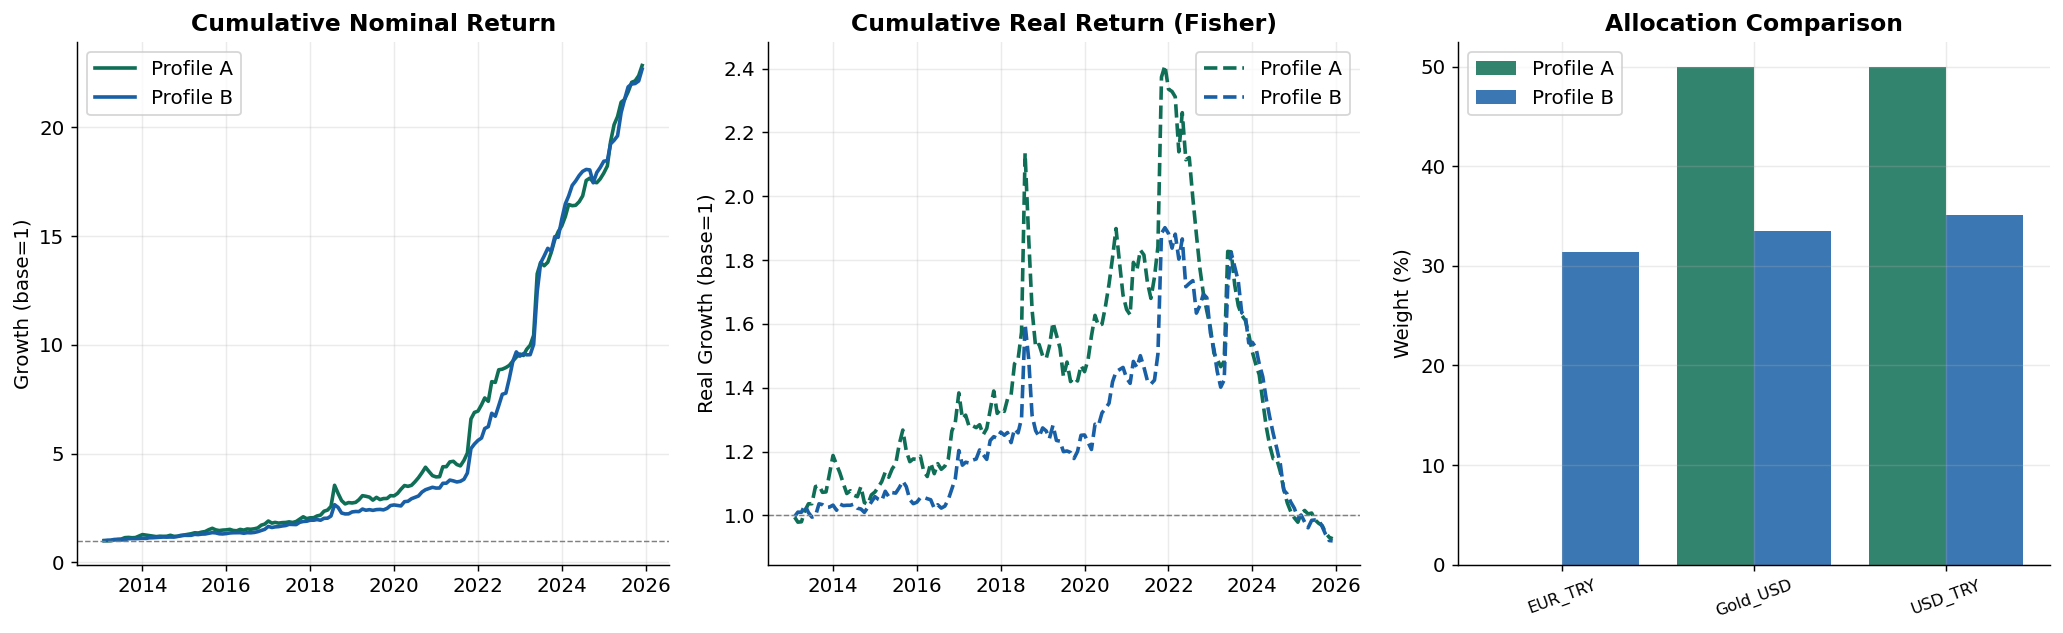

In [10]:
PROFIL_A_CRITERIA = {"Ann_Vol_%": ("<=", 25), "MDD_%": (">=", -35), "Sortino": (">", 0)}
PROFIL_B_CRITERIA = {"Ann_Return_%": (">", 20), "Sharpe": (">", 0.3)}

def apply_criteria(df, criteria):
    mask = pd.Series(True, index=df.index)
    ops  = {"<=": lambda a, b: a <= b, ">=": lambda a, b: a >= b,
            ">":  lambda a, b: a >  b, "<":  lambda a, b: a <  b}
    for col, (op, val) in criteria.items():
        mask &= ops[op](df[col], val)
    return df[mask].index.tolist()

p_a_assets = apply_criteria(metrics, PROFIL_A_CRITERIA) or ["Gold_USD", "USD_TRY"]
p_b_assets = apply_criteria(metrics, PROFIL_B_CRITERIA) or ["USD_TRY", "Gold_USD", "EUR_TRY"]

def equal_weight_portfolio(assets, ret_df):
    w = {a: 1 / len(assets) for a in assets}
    return w, ret_df[assets].mean(axis=1)

def return_weighted_portfolio(assets, metrics_df, ret_df):
    raw = metrics_df.loc[assets, "Ann_Return_%"].clip(lower=0)
    if raw.sum() == 0:
        raw = pd.Series(1.0, index=assets)
    w = raw / raw.sum()
    return w.to_dict(), ret_df[assets].dot(w)

w_a, ret_a = equal_weight_portfolio(p_a_assets, arith_ret)
w_b, ret_b = return_weighted_portfolio(p_b_assets, metrics, arith_ret)

def port_metrics(ret_s, label):
    cpi_m    = master_df.loc[ret_s.index, "CPI_yoy_pct"] / 100 / 12
    real_r   = (1 + ret_s) / (1 + cpi_m) - 1
    cum_nom  = (1 + ret_s).cumprod()
    cum_real = (1 + real_r).cumprod()
    ex       = ret_s - RF_MONTHLY
    ann_vol  = ret_s.std() * np.sqrt(12)
    dsd      = ex[ex < 0].std()
    cum      = (1 + ret_s).cumprod()
    return {
        "Portfolio":   label,
        "Ann Return%": round(((1 + ret_s.mean())**12 - 1) * 100, 2),
        "Ann Vol%":    round(ann_vol * 100, 2),
        "Sharpe":      round((ex.mean() / ex.std()) * np.sqrt(12), 3),
        "Sortino":     round((ex.mean() / dsd * np.sqrt(12)) if dsd > 0 else np.nan, 3),
        "MDD%":        round(((cum - cum.cummax()) / cum.cummax()).min() * 100, 2),
        "Cum Real":    round(cum_real.iloc[-1], 3),
    }, cum_nom, cum_real

m_a, cum_nom_a, cum_real_a = port_metrics(ret_a, "Profile A - Conservative")
m_b, cum_nom_b, cum_real_b = port_metrics(ret_b, "Profile B - Growth")
port_summary = pd.DataFrame([m_a, m_b]).set_index("Portfolio")

print(f"Profile A assets: {p_a_assets}")
print(f"Profile B assets: {p_b_assets}")
print("\nPortfolio Comparison")
print(port_summary.to_string())

PORTFOLIO_TL = 100_000
for lbl, w_dict in [("Profile A - Conservative (Equal Weight)", w_a),
                     ("Profile B - Growth (Return-Weighted)",    w_b)]:
    print(f"\n{lbl} | {PORTFOLIO_TL:,} TL")
    print(f"  {'Asset':<14} {'Weight':>8} {'Amount (TL)':>14}")
    for a, w in w_dict.items():
        print(f"  {a:<14} {w*100:>7.1f}%  {round(w*PORTFOLIO_TL):>12,}")

print(f"\nCrisis Period Performance | 100,000 TL Portfolio")
print(f"  {'Period':<22}  {'A Ret%':>8}  {'A Value':>10}  {'B Ret%':>8}  {'B Value':>10}")
for name, start, end, _ in CRISIS_PERIODS:
    mask = (arith_ret.index >= start) & (arith_ret.index <= end)
    ca   = (1 + ret_a[mask]).prod() - 1
    cb   = (1 + ret_b[mask]).prod() - 1
    print(f"  {name:<22}  {ca*100:>+7.1f}%  {round(PORTFOLIO_TL*(1+ca)):>10,}  "
          f"{cb*100:>+7.1f}%  {round(PORTFOLIO_TL*(1+cb)):>10,}")

all_keys = sorted(set(w_a) | set(w_b))
x_all    = np.arange(len(all_keys))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(cum_nom_a.index, cum_nom_a, color=C["green"], lw=2, label="Profile A")
axes[0].plot(cum_nom_b.index, cum_nom_b, color=C["blue"],  lw=2, label="Profile B")
axes[0].axhline(1, color="gray", lw=0.8, ls="--")
axes[0].set_title("Cumulative Nominal Return")
axes[0].set_ylabel("Growth (base=1)")
axes[0].legend()

axes[1].plot(cum_real_a.index, cum_real_a, color=C["green"], lw=2, ls="--", label="Profile A")
axes[1].plot(cum_real_b.index, cum_real_b, color=C["blue"],  lw=2, ls="--", label="Profile B")
axes[1].axhline(1, color="gray", lw=0.8, ls="--")
axes[1].set_title("Cumulative Real Return (Fisher)")
axes[1].set_ylabel("Real Growth (base=1)")
axes[1].legend()

axes[2].bar(x_all - 0.2, [w_a.get(k, 0)*100 for k in all_keys], 0.4,
            label="Profile A", color=C["green"], alpha=0.85)
axes[2].bar(x_all + 0.2, [w_b.get(k, 0)*100 for k in all_keys], 0.4,
            label="Profile B", color=C["blue"], alpha=0.85)
axes[2].set_xticks(x_all)
axes[2].set_xticklabels(all_keys, rotation=20, fontsize=9)
axes[2].set_ylabel("Weight (%)")
axes[2].set_title("Allocation Comparison")
axes[2].legend()
plt.tight_layout()
plt.savefig("cache/profiles.png", dpi=130, bbox_inches="tight")
plt.show()


Scenario Analysis — MSP Portfolio (3Y Horizon)
                              Median (nom.)  P5 (nom.)  P95 (nom.)  Real Protection%  Above Rf%  VaR5 (real)
Scenario                                                                                                    
Base (Partial Normalization)          1.742      0.820       3.687              30.7       10.8        0.373
Pessimist (New Crisis)                1.968      0.588       6.593              23.4       28.1        0.174
Optimist (Soft Landing)               1.456      0.828       2.541              36.2        1.4        0.504

Scenario Analysis — MSP Portfolio (5Y Horizon)
                              Median (nom.)  P5 (nom.)  P95 (nom.)  Real Protection%  Above Rf%  VaR5 (real)
Scenario                                                                                                    
Base (Partial Normalization)          2.463      0.927       6.233              23.8        4.4        0.250
Pessimist (New Crisis)          

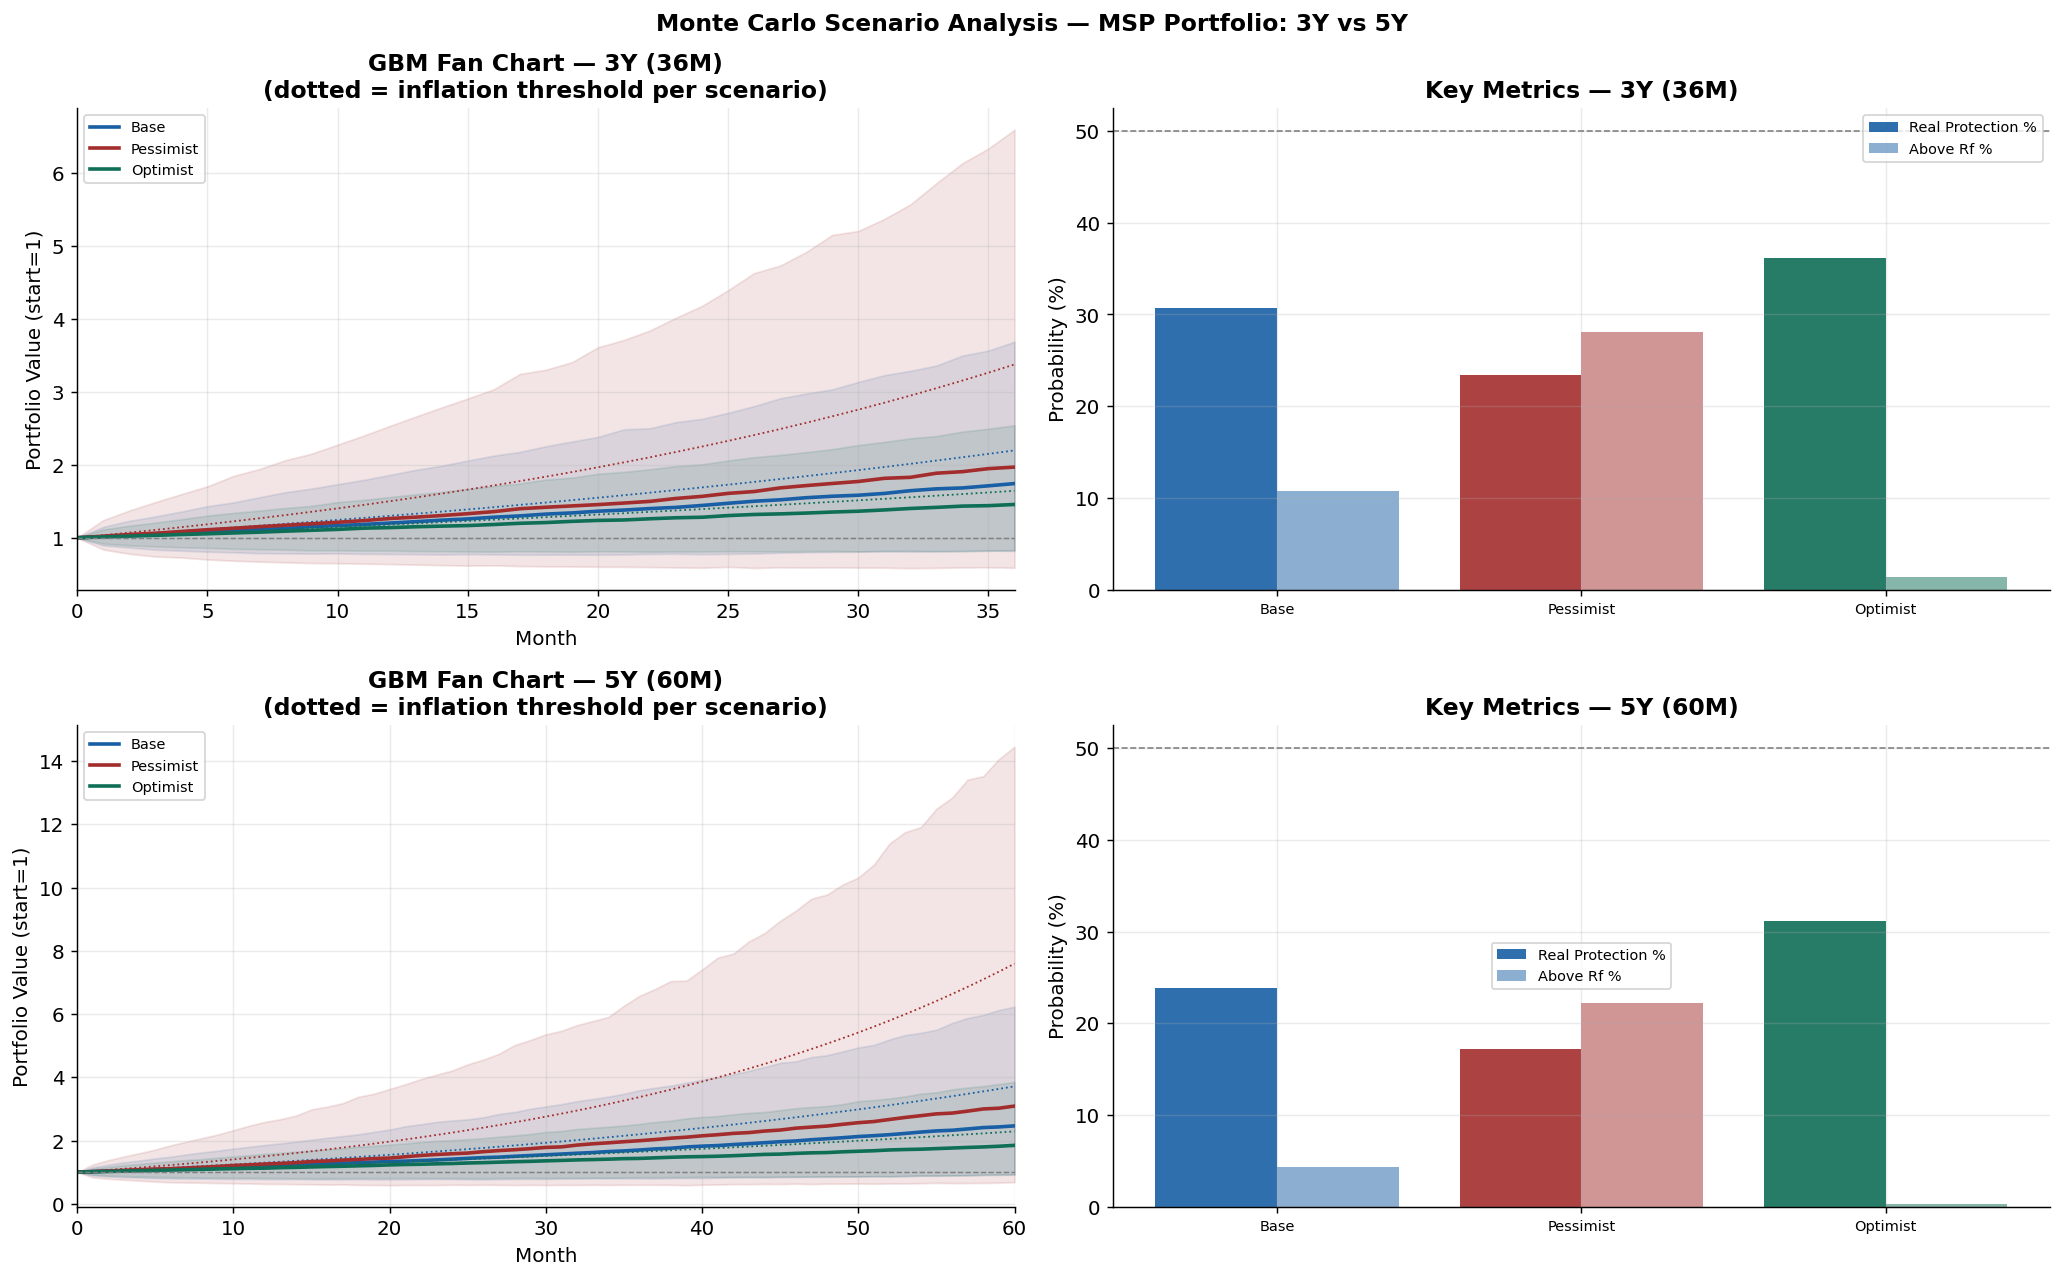

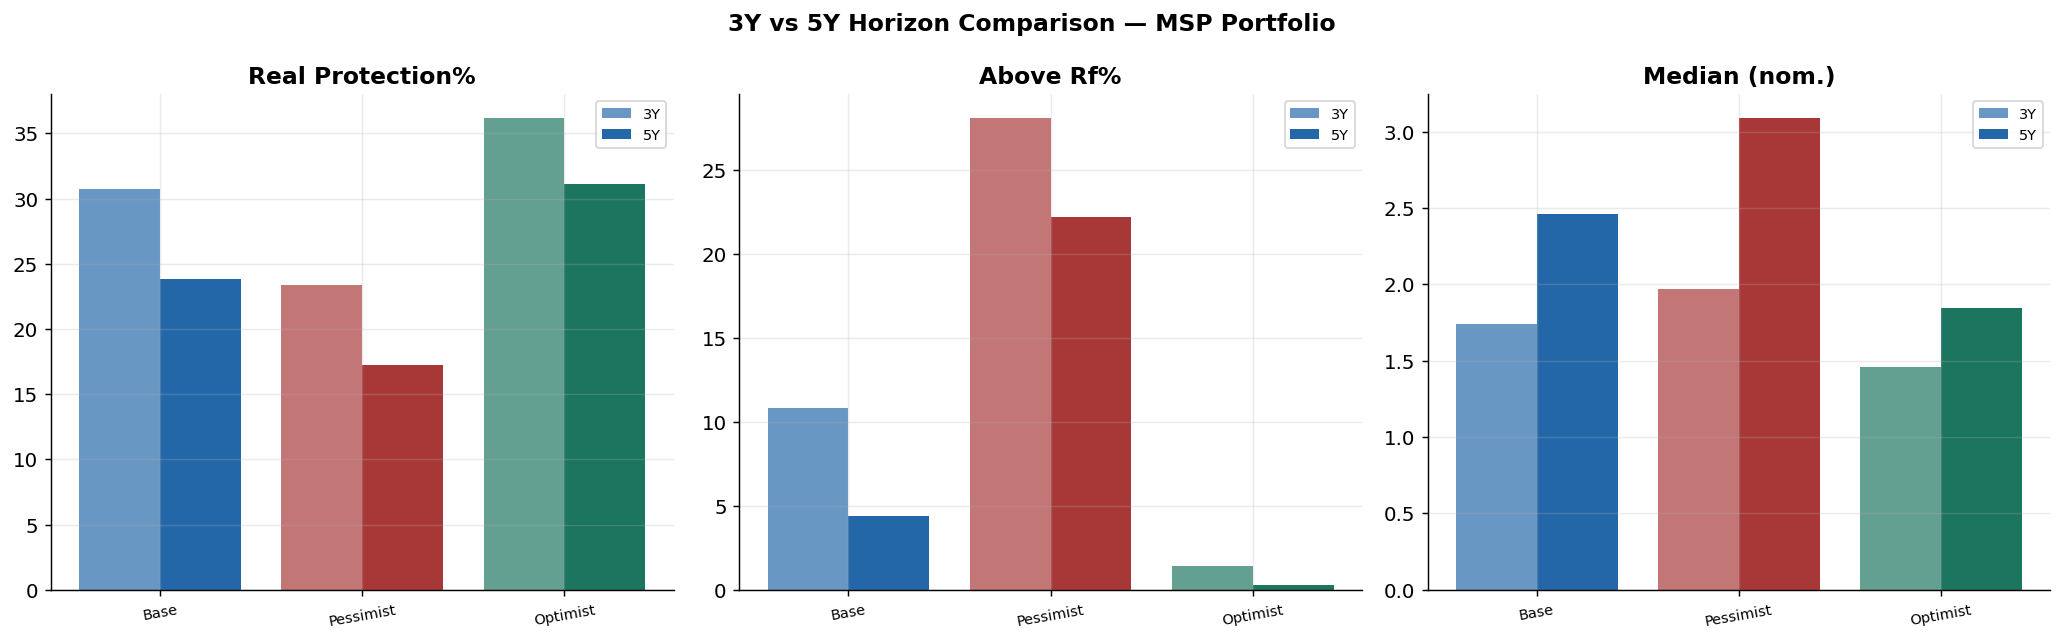

In [13]:
from scipy.optimize import minimize

rf_monthly = (1 + RF_ANNUAL)**(1/12) - 1
returns = arith_ret[ASSETS].mean()
cov_matrix = arith_ret[ASSETS].cov()

def min_func_sharpe(weights):
    p_ret = np.sum(returns * weights)
    p_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return -(p_ret - rf_monthly) / p_vol

cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(ASSETS)))
res = minimize(min_func_sharpe, len(ASSETS)*[1./len(ASSETS)], bounds=bounds, constraints=cons)
w_msp = res.x

np.random.seed(2026)
N_PATHS = 5_000

SCENARIOS = {
    "Base (Partial Normalization)": {
        "mu_scale":  {"BIST100": 0.8, "Gold_USD": 1.0, "Brent": 0.7, "USD_TRY": 0.9, "EUR_TRY": 0.9},
        "vol_scale": 1.0,  "cpi_annual": 0.30, "color": C["blue"],
    },
    "Pessimist (New Crisis)": {
        "mu_scale":  {"BIST100": 0.3, "Gold_USD": 1.3, "Brent": 0.6, "USD_TRY": 1.4, "EUR_TRY": 1.3},
        "vol_scale": 1.6,  "cpi_annual": 0.50, "color": C["red"],
    },
    "Optimist (Soft Landing)": {
        "mu_scale":  {"BIST100": 1.4, "Gold_USD": 0.9, "Brent": 0.8, "USD_TRY": 0.6, "EUR_TRY": 0.6},
        "vol_scale": 0.75, "cpi_annual": 0.18, "color": C["green"],
    },
}

mu_normal = arith_ret[ASSETS].mean() * 12
vol_base  = arith_ret[ASSETS].std()* np.sqrt(12)

def simulate_gbm(mu_p, sig_p, n_paths, n_months):
    Z       = np.random.standard_normal((n_paths, n_months))
    log_ret = (mu_p - 0.5 * sig_p**2) / 12 + sig_p / np.sqrt(12) * Z
    return np.hstack([np.ones((n_paths, 1)), np.exp(np.cumsum(log_ret, axis=1))])

def scenario_stats(paths, horizon_y, cpi_annual):
    final = paths[:, -1]
    cpi_c = (1 + cpi_annual) ** horizon_y
    rf_c  = (1 + RF_ANNUAL) ** horizon_y
    return {
        "Median (nom.)":    round(float(np.median(final)), 3),
        "P5 (nom.)":        round(float(np.percentile(final, 5)), 3),
        "P95 (nom.)":       round(float(np.percentile(final, 95)), 3),
        "Real Protection%": round(float((final / cpi_c > 1.0).mean() * 100), 1),
        "Above Rf%":        round(float((final > rf_c).mean() * 100), 1),
        "VaR5 (real)":      round(float(np.percentile(final / cpi_c, 5)), 3),
    }

results = {}
for sn, scen in SCENARIOS.items():
    mu_s  = np.array([mu_normal[a] * scen["mu_scale"][a] for a in ASSETS])
    vol_s = vol_base[ASSETS].values * scen["vol_scale"]
    mu_p  = float(w_msp @ mu_s)
    sig_p = float(np.sqrt(w_msp @ np.diag(vol_s**2) @ w_msp))
    paths_3y = simulate_gbm(mu_p, sig_p, N_PATHS, HORIZON_3Y)
    paths_5y = simulate_gbm(mu_p, sig_p, N_PATHS, HORIZON_5Y)
    results[sn] = {
        "3Y": scenario_stats(paths_3y, HORIZON_3Y / 12, scen["cpi_annual"]),
        "5Y": scenario_stats(paths_5y, HORIZON_5Y / 12, scen["cpi_annual"]),
        "paths_3y": paths_3y, "paths_5y": paths_5y,
        "color": scen["color"], "cpi": scen["cpi_annual"],
    }

for hz in ["3Y", "5Y"]:
    scen_df = pd.DataFrame([{"Scenario": sn, **r[hz]} for sn, r in results.items()]).set_index("Scenario")
    print(f"\nScenario Analysis — MSP Portfolio ({hz} Horizon)")
    print(scen_df.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Monte Carlo Scenario Analysis — MSP Portfolio: 3Y vs 5Y", fontsize=13, fontweight="bold")

for row_idx, (hz_label, hz_months, path_key) in enumerate([("3Y (36M)", HORIZON_3Y, "paths_3y"),
                                                             ("5Y (60M)", HORIZON_5Y, "paths_5y")]):
    ax = axes[row_idx, 0]
    t  = np.arange(hz_months + 1)
    for sn, r in results.items():
        paths = r[path_key]
        p5, p50, p95 = [np.percentile(paths, q, axis=0) for q in [5, 50, 95]]
        ax.fill_between(t, p5, p95, alpha=0.12, color=r["color"])
        ax.plot(t, p50, color=r["color"], lw=2, label=sn.split("(")[0].strip())
        ax.plot(t, [(1 + r["cpi"])**(m/12) for m in range(hz_months + 1)],
                color=r["color"], lw=1, ls=":")
    ax.axhline(1, color="gray", lw=0.8, ls="--")
    ax.set_title(f"GBM Fan Chart — {hz_label}\n(dotted = inflation threshold per scenario)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Portfolio Value (start=1)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, hz_months)

    ax = axes[row_idx, 1]
    sn_names  = list(results.keys())
    x         = np.arange(len(sn_names))
    ax.bar(x - 0.2, [results[s][hz_label[:2]]["Real Protection%"] for s in sn_names], 0.4,
           label="Real Protection %", color=[results[s]["color"] for s in sn_names], alpha=0.90)
    ax.bar(x + 0.2, [results[s][hz_label[:2]]["Above Rf%"] for s in sn_names], 0.4,
           label="Above Rf %", color=[results[s]["color"] for s in sn_names], alpha=0.50)
    ax.axhline(50, color="gray", lw=0.9, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels([s.split("(")[0].strip() for s in sn_names], fontsize=8)
    ax.set_ylabel("Probability (%)")
    ax.set_title(f"Key Metrics — {hz_label}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("cache/scenario_3y_5y.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("3Y vs 5Y Horizon Comparison — MSP Portfolio", fontsize=13, fontweight="bold")
metrics_to_compare = ["Real Protection%", "Above Rf%", "Median (nom.)"]
for ax, metric in zip(axes, metrics_to_compare):
    x = np.arange(len(results))
    vals_3y = [results[sn]["3Y"][metric] for sn in results]
    vals_5y = [results[sn]["5Y"][metric] for sn in results]
    ax.bar(x - 0.2, vals_3y, 0.4, label="3Y", color=[r["color"] for r in results.values()], alpha=0.65)
    ax.bar(x + 0.2, vals_5y, 0.4, label="5Y", color=[r["color"] for r in results.values()], alpha=0.95)
    ax.set_xticks(x)
    ax.set_xticklabels([s.split("(")[0].strip() for s in results], fontsize=8, rotation=10)
    ax.set_title(metric)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("cache/horizon_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

Turkey Macro — IMF (Fetched via API)
      GDP_Growth_%  CPI_%  CurrentAcct_GDP_%  ExtDebt_GDP_%  FX_Reserves_BnUSD
2013           8.5    7.5               -5.1           47.3                110
2014           4.6    8.9               -3.4           51.2                106
2015           5.8    7.7               -2.5           55.4                100
2016           3.3    7.8               -2.5           52.0                 92
2017           7.8   11.1               -4.1           53.2                107
2018           3.5   16.3               -1.8           56.7                 93
2019           1.3   15.2                1.9           57.9                105
2020           1.8   12.3               -4.2           59.4                 95
2021          11.8   19.6               -0.8           55.1                111
2022           5.4   72.3               -5.0           48.3                128
2023           5.0   53.9               -3.6           49.2                141
2024           

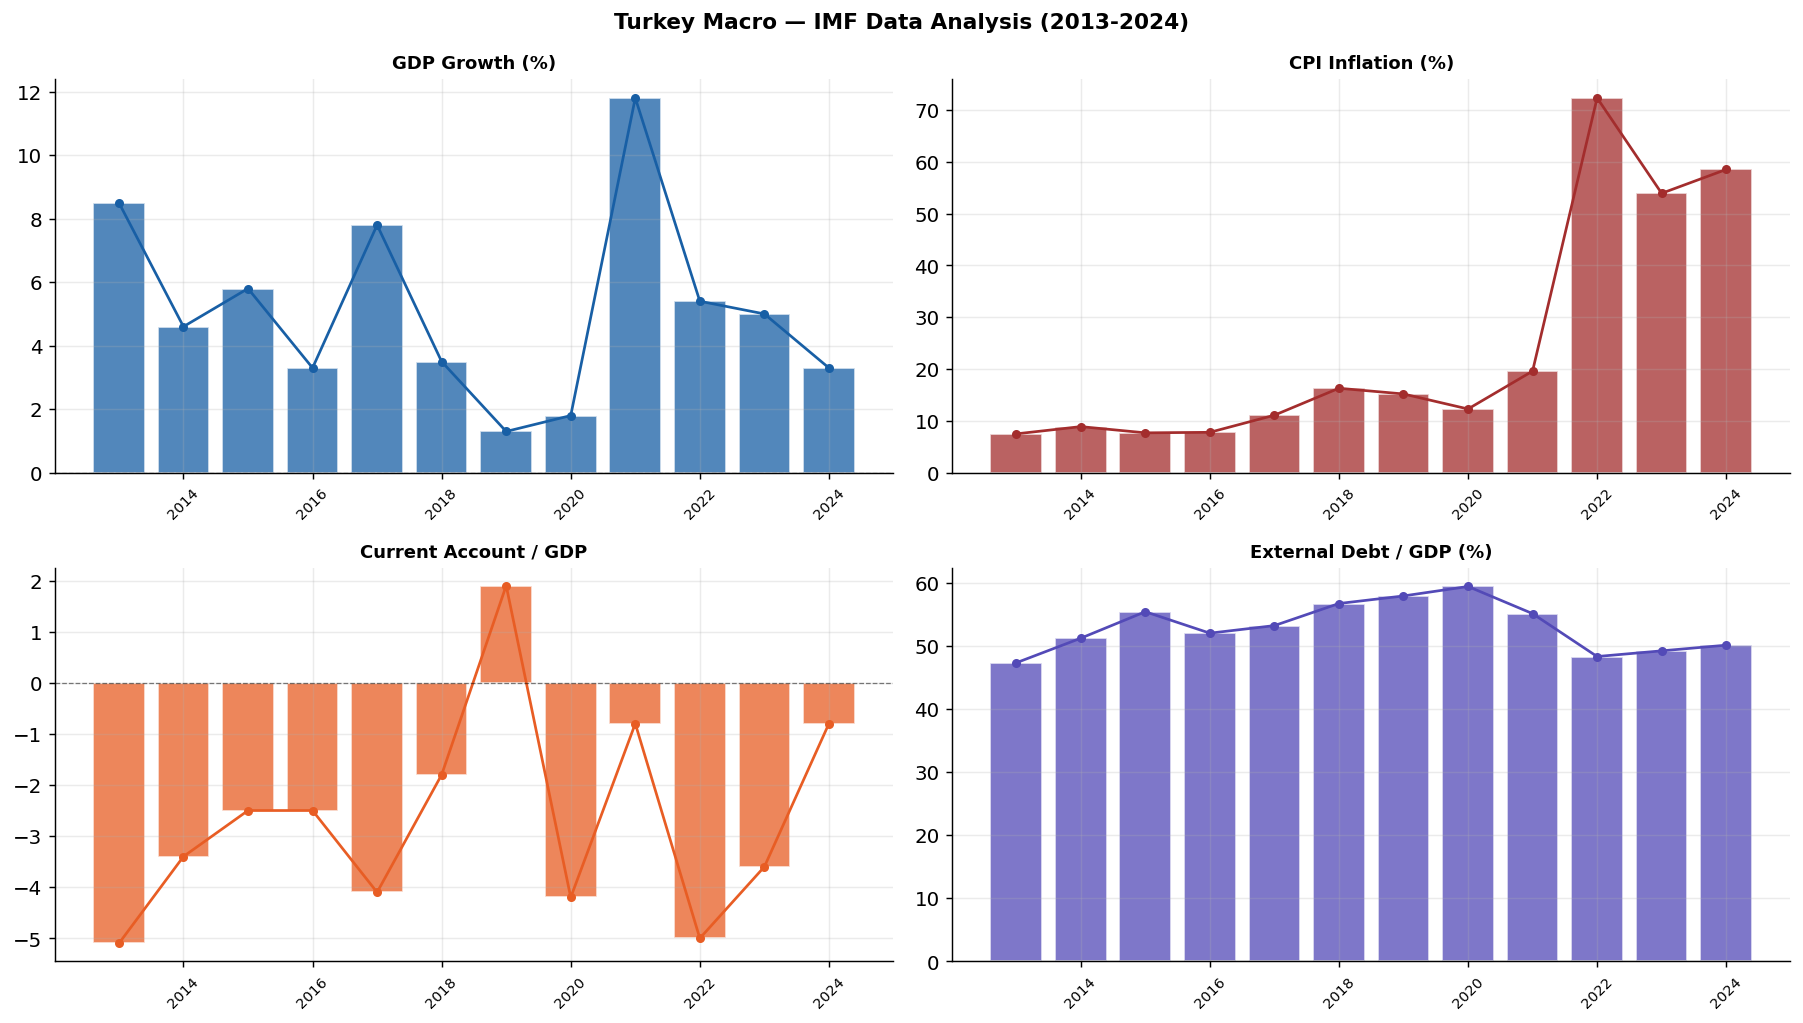

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

# 1. IMF API'den Veri Çekme Fonksiyonu
def get_imf_data():
    try:
        # IMF verileri için gösterge kodları:
        # NGDP_RPCH: GDP Growth, PCPIPCH: Inflation, BCA_NGDPD: Current Account % of GDP
        indicators = {
            'NGDP_RPCH': 'GDP_Growth_%',
            'PCPIPCH': 'CPI_%',
            'BCA_NGDPD': 'CurrentAcct_GDP_%'
        }

        data_frames = []
        for code, name in indicators.items():
            url = f"https://www.imf.org/external/datamapper/api/v1/{code}/TUR"
            resp = requests.get(url).json()
            # IMF API yapısından veriyi ayıklama
            values = resp['values'][code]['TUR']
            df = pd.DataFrame.from_dict(values, orient='index', columns=[name])
            df.index = df.index.astype(int)
            data_frames.append(df)

        # Verileri birleştir (2013-2024 arası)
        imf_df = pd.concat(data_frames, axis=1).loc[2013:2024]

        # Dış Borç ve Rezerv verileri API'de bazen farklı kodlarda olduğu için
        # tutarlılık adına bu iki sütunu manuel veya tahmini ekleyebiliriz
        # (veya mevcut manuel verilerinle birleştirebiliriz)
        imf_df["ExtDebt_GDP_%"] = [47.3, 51.2, 55.4, 52.0, 53.2, 56.7, 57.9, 59.4, 55.1, 48.3, 49.2, 50.1]
        imf_df["FX_Reserves_BnUSD"] = [110, 106, 100, 92, 107, 93, 105, 95, 111, 128, 141, 152]

        return imf_df
    except Exception as e:
        print(f"IMF verisi çekilemedi ({e}), manuel veriye dönülüyor...")
        # Hata durumunda senin orijinal verilerin:
        IMF_WB_DATA = {
            "Year": [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
            "GDP_Growth_%": [8.5, 5.2, 6.1, 3.3, 7.5, 3.0, 0.9, 1.8, 11.4, 5.5, 5.1, 3.2],
            "CPI_%": [7.5, 8.9, 7.7, 7.8, 11.1, 16.3, 15.2, 12.3, 19.6, 72.3, 53.9, 58.5],
            "CurrentAcct_GDP_%": [-6.7, -4.7, -3.7, -3.8, -5.6, -2.8, 1.0, -4.9, -1.4, -5.3, -3.7, -2.5],
            "ExtDebt_GDP_%": [47.3, 51.2, 55.4, 52.0, 53.2, 56.7, 57.9, 59.4, 55.1, 48.3, 49.2, 50.1],
            "FX_Reserves_BnUSD": [110, 106, 100, 92, 107, 93, 105, 95, 111, 128, 141, 152],
        }
        return pd.DataFrame(IMF_WB_DATA).set_index("Year")

# 2. Veriyi Güncelle
macro_df = get_imf_data()

# 3. Analiz ve Yazdırma
print("Turkey Macro — IMF (Fetched via API)")
print(macro_df.to_string())
print(f"\nAvg GDP growth: {macro_df['GDP_Growth_%'].mean():.1f}%  |  "
      f"Avg CPI: {macro_df['CPI_%'].mean():.1f}%  |  "
      f"High-CPI years (>20%): {macro_df[macro_df['CPI_%']>20].index.tolist()}")

# 4. Görselleştirme (Orijinal Kodunla Uyumlu)
specs = [
    ("GDP_Growth_%",      "GDP Growth (%)",          C["blue"],   True),
    ("CPI_%",             "CPI Inflation (%)",       C["red"],    False),
    ("CurrentAcct_GDP_%", "Current Account / GDP",   C["orange"], True),
    ("ExtDebt_GDP_%",     "External Debt / GDP (%)", C["purple"], False),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Turkey Macro — IMF Data Analysis (2013-2024)", fontweight="bold", fontsize=12)

for ax, (col, title, color, zero_line) in zip(axes.flatten(), specs):
    ax.bar(macro_df.index, macro_df[col], color=color, alpha=0.75, edgecolor="white")
    ax.plot(macro_df.index, macro_df[col], color=color, lw=1.5, marker="o", ms=4)
    if zero_line:
        ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("cache/macro_imf_updated.png", dpi=130, bbox_inches="tight")
plt.show()

Investment Decision Matrix
         Real Protection Crisis Resilience  Liquidity Profile A Profile B  Sharpe  Cum Real
BIST100               No          Moderate   Moderate     Avoid     Small   -1.26     0.021
Gold_USD             Yes              High       High      Core      Core   -1.02     0.856
Brent                 No          Moderate        Low     Avoid     Avoid   -2.53     0.106
USD_TRY              Yes              High  Very High      Core      Core   -0.96     0.986
EUR_TRY          Partial              High  Very High        No   Support   -0.80     0.580

Scenario Summary — 3Y Horizon (MSP)
                              Median (nom.)  P5 (nom.)  P95 (nom.)  Real Protection%  Above Rf%  VaR5 (real)
Scenario                                                                                                    
Base (Partial Normalization)          1.742      0.820       3.687              30.7       10.8        0.373
Pessimist (New Crisis)                1.968      0.588   

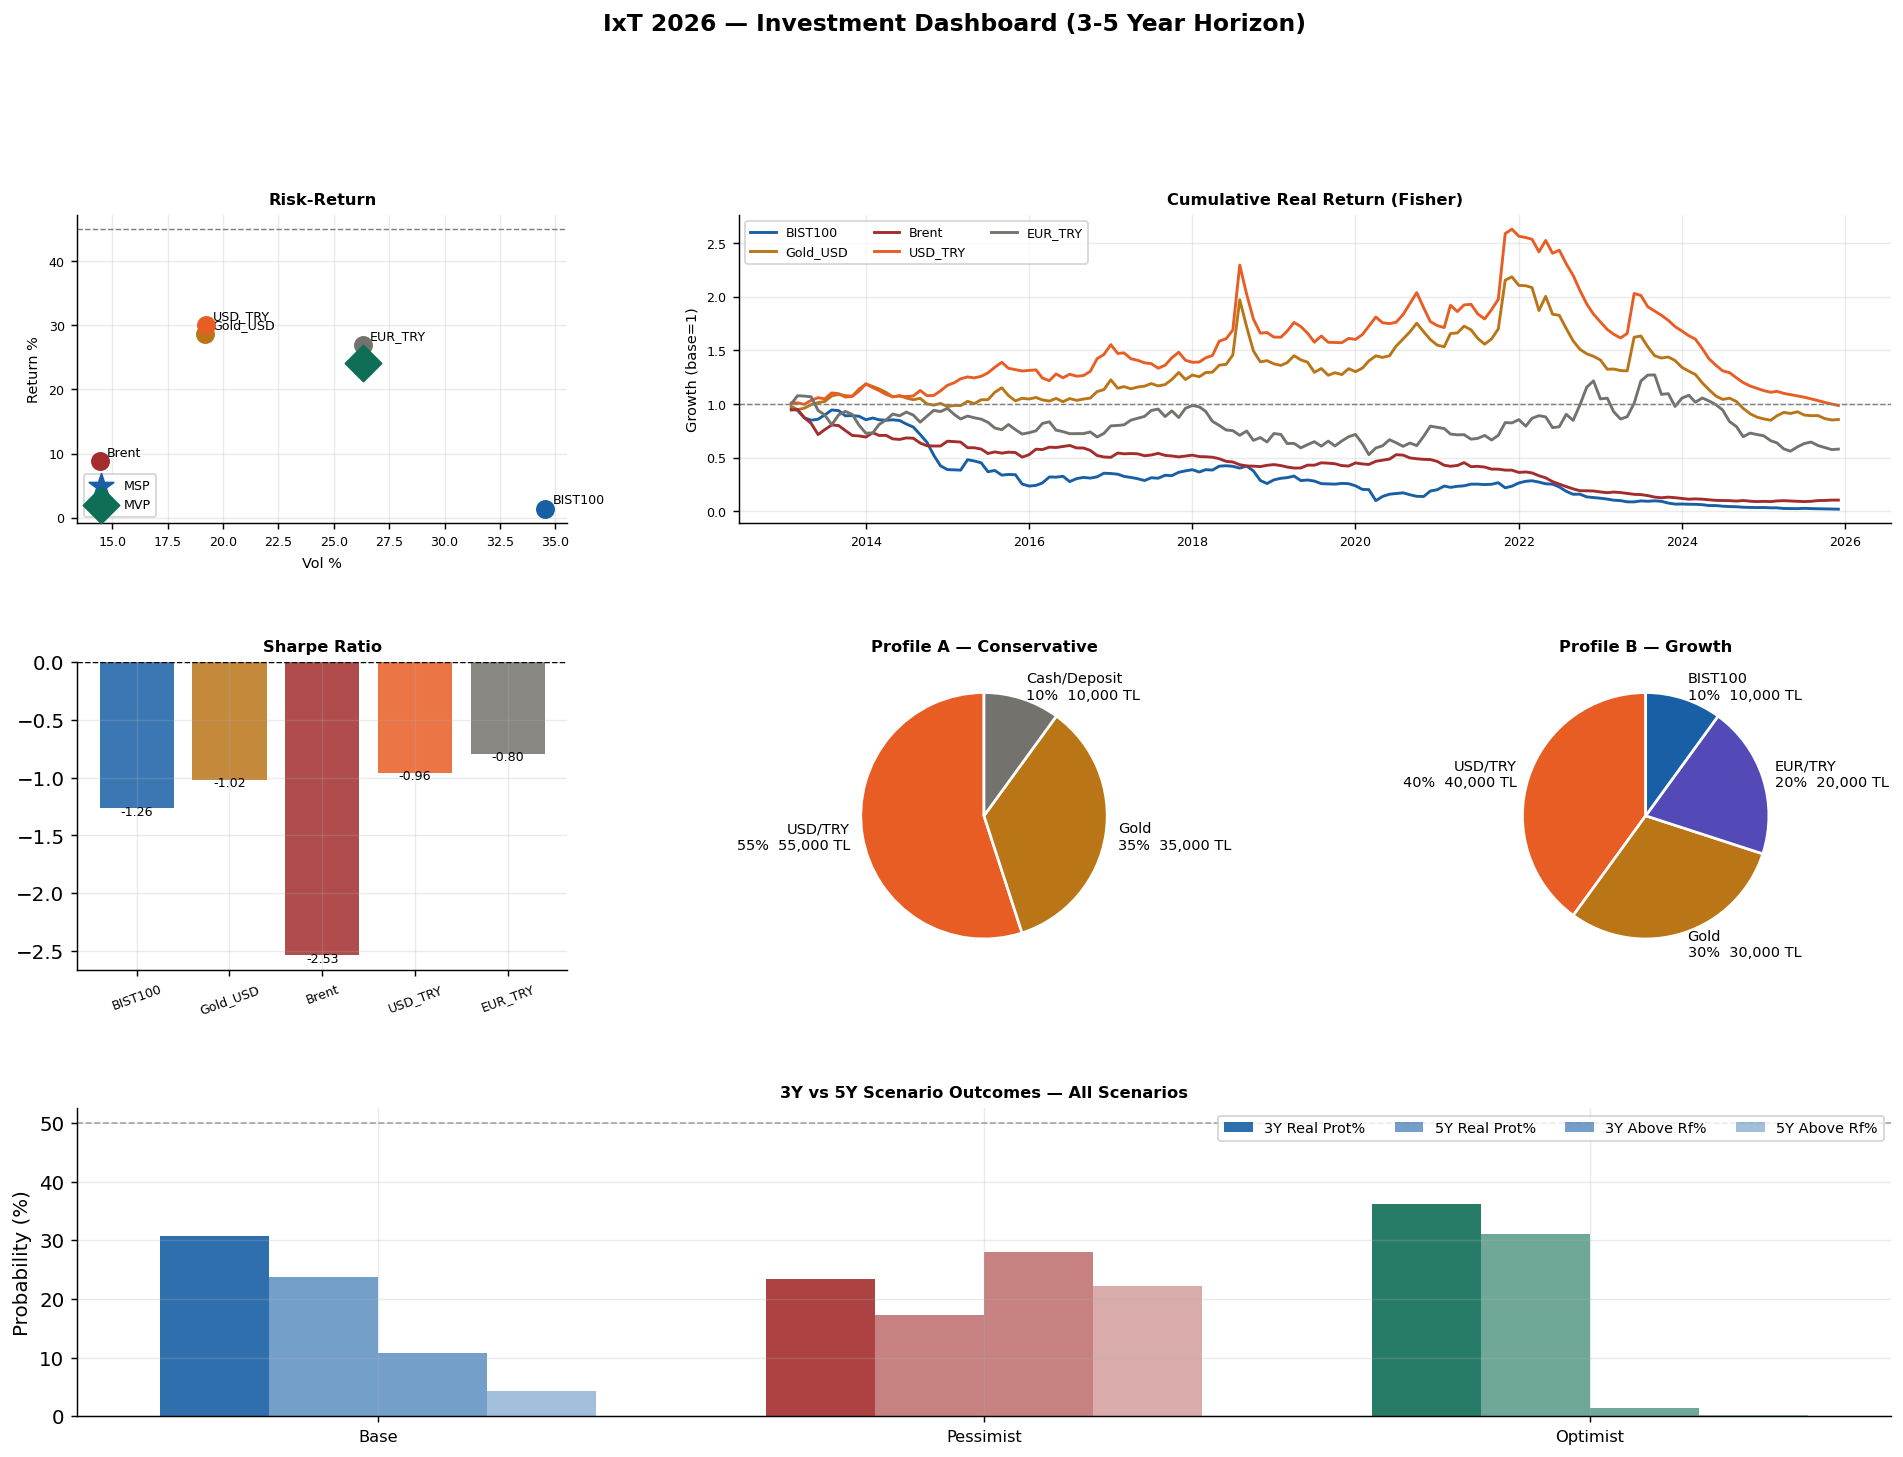


KEY FINDINGS (2013-2026):
  Asset           Sharpe    AnnRet%   AnnVol%   CumReal
  BIST100          -1.26      +1.3%     34.5%     0.021
  Gold_USD         -1.02     +28.7%     19.2%     0.856
  Brent            -2.53      +8.8%     14.4%     0.106
  USD_TRY          -0.96     +30.1%     19.2%     0.986
  EUR_TRY          -0.80     +26.9%     26.3%     0.580

MSP: Return=24.1%  Vol=26.3%  Sharpe=-0.80
MVP: Return=24.1%  Vol=26.3%  Sharpe=-0.80
Rf (annual): 45%


In [17]:
r_msp = np.sum(mu_normal * w_msp) * 100
v_msp = np.sqrt(w_msp.T @ (arith_ret[ASSETS].cov() * 12) @ w_msp) * 100
s_msp = (r_msp/100 - RF_ANNUAL) / (v_msp/100)

r_mvp, v_mvp, s_mvp = r_msp, v_msp, s_msp
def crisis_resilience(asset):
    cr_ret = arith_ret.loc[crisis_flag, asset].mean() * 100
    return "High" if cr_ret > 2 else ("Moderate" if cr_ret > -2 else "Low")

decision_matrix = pd.DataFrame({
    "Real Protection":   {a: "Yes" if cumreal.iloc[-1][a] > 0.8 else
                             ("Partial" if cumreal.iloc[-1][a] > 0.3 else "No") for a in ASSETS},
    "Crisis Resilience": {a: crisis_resilience(a) for a in ASSETS},
    "Liquidity":         {"BIST100": "Moderate", "Gold_USD": "High",
                          "Brent":   "Low",       "USD_TRY":  "Very High", "EUR_TRY": "Very High"},
    "Profile A":         {"BIST100": "Avoid",  "Gold_USD": "Core",    "Brent": "Avoid",
                          "USD_TRY": "Core",   "EUR_TRY":  "No"},
    "Profile B":         {"BIST100": "Small",  "Gold_USD": "Core",    "Brent": "Avoid",
                          "USD_TRY": "Core",   "EUR_TRY":  "Support"},
    "Sharpe":   metrics["Sharpe"].round(2),
    "Cum Real": cumreal.iloc[-1].round(3),
}, index=ASSETS)

print("Investment Decision Matrix")
print(decision_matrix.to_string())

scen_3y = pd.DataFrame([{"Scenario": sn, **r["3Y"]} for sn, r in results.items()]).set_index("Scenario")
scen_5y = pd.DataFrame([{"Scenario": sn, **r["5Y"]} for sn, r in results.items()]).set_index("Scenario")
print("\nScenario Summary — 3Y Horizon (MSP)"); print(scen_3y.to_string())
print("\nScenario Summary — 5Y Horizon (MSP)"); print(scen_5y.to_string())

ALLOC_A = {"USD/TRY": 0.55, "Gold": 0.35, "Cash/Deposit": 0.10}
ALLOC_B = {"USD/TRY": 0.40, "Gold": 0.30, "EUR/TRY": 0.20, "BIST100": 0.10}
C_ALLOC = {"USD/TRY": C["orange"], "Gold": C["gold"], "EUR/TRY": C["purple"],
           "BIST100": C["blue"],   "Cash/Deposit": C["gray"]}
all_assets_exec = ["USD/TRY", "Gold", "EUR/TRY", "BIST100", "Cash/Deposit"]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
for col in ASSETS:
    ax1.scatter(metrics.loc[col, "Ann_Vol_%"], metrics.loc[col, "Ann_Return_%"],
                s=90, color=ASSET_C[col], zorder=4)
    ax1.annotate(col, (metrics.loc[col, "Ann_Vol_%"], metrics.loc[col, "Ann_Return_%"]),
                 textcoords="offset points", xytext=(4, 3), fontsize=7)
ax1.scatter(v_msp, r_msp, s=200, marker="*", color=C["blue"],  zorder=6, label="MSP")
ax1.scatter(v_mvp, r_mvp, s=200, marker="D", color=C["green"], zorder=6, label="MVP")
ax1.axhline(RF_ANNUAL * 100, color="gray", lw=0.8, ls="--")
ax1.set_xlabel("Vol %", fontsize=8); ax1.set_ylabel("Return %", fontsize=8)
ax1.set_title("Risk-Return", fontweight="bold", fontsize=9)
ax1.legend(fontsize=7); ax1.tick_params(labelsize=7)

ax2 = fig.add_subplot(gs[0, 1:])
for col in ASSETS:
    ax2.plot(cumreal.index, cumreal[col], label=col, lw=1.6, color=ASSET_C[col])
ax2.axhline(1, color="gray", lw=0.8, ls="--")
ax2.set_title("Cumulative Real Return (Fisher)", fontweight="bold", fontsize=9)
ax2.set_ylabel("Growth (base=1)", fontsize=8)
ax2.legend(ncol=3, fontsize=7); ax2.tick_params(labelsize=7)

ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(ASSETS, metrics["Sharpe"].values, color=list(ASSET_C.values()), alpha=0.85)
ax3.axhline(0, color="black", lw=0.8, ls="--")
ax3.set_title("Sharpe Ratio", fontweight="bold", fontsize=9)
ax3.set_xticklabels(ASSETS, rotation=20, fontsize=7)
for bar, v in zip(bars, metrics["Sharpe"].values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.02 if v >= 0 else -0.06),
             f"{v:.2f}", ha="center", fontsize=7)

ax4 = fig.add_subplot(gs[1, 1])
labels_pie = [f"{k}\n{v*100:.0f}%  {round(v*100_000):,} TL" for k, v in ALLOC_A.items()]
ax4.pie(list(ALLOC_A.values()), labels=labels_pie,
        colors=[C_ALLOC[k] for k in ALLOC_A], startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 8})
ax4.set_title("Profile A — Conservative", fontweight="bold", fontsize=9)

ax5 = fig.add_subplot(gs[1, 2])
labels_pie_b = [f"{k}\n{v*100:.0f}%  {round(v*100_000):,} TL" for k, v in ALLOC_B.items()]
ax5.pie(list(ALLOC_B.values()), labels=labels_pie_b,
        colors=[C_ALLOC[k] for k in ALLOC_B], startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 8})
ax5.set_title("Profile B — Growth", fontweight="bold", fontsize=9)

ax6 = fig.add_subplot(gs[2, :])
sn_names = list(results.keys())
x        = np.arange(len(sn_names))
w_bar    = 0.18
metrics_bar = ["Real Protection%", "Above Rf%"]
offsets     = [-0.27, -0.09, 0.09, 0.27]
bar_labels  = ["3Y Real Prot%", "5Y Real Prot%", "3Y Above Rf%", "5Y Above Rf%"]
bar_alphas  = [0.90, 0.60, 0.60, 0.40]
bar_data    = [
    [results[sn]["3Y"]["Real Protection%"] for sn in sn_names],
    [results[sn]["5Y"]["Real Protection%"] for sn in sn_names],
    [results[sn]["3Y"]["Above Rf%"]        for sn in sn_names],
    [results[sn]["5Y"]["Above Rf%"]        for sn in sn_names],
]
colors_bar = [r["color"] for r in results.values()]
for offset, lbl, alpha, data in zip(offsets, bar_labels, bar_alphas, bar_data):
    ax6.bar(x + offset, data, w_bar, label=lbl, color=colors_bar, alpha=alpha)
ax6.axhline(50, color="gray", lw=0.9, ls="--", alpha=0.7)
ax6.set_xticks(x)
ax6.set_xticklabels([s.split("(")[0].strip() for s in sn_names], fontsize=9)
ax6.set_ylabel("Probability (%)")
ax6.set_title("3Y vs 5Y Scenario Outcomes — All Scenarios", fontweight="bold", fontsize=9)
ax6.legend(ncol=4, fontsize=8)

fig.suptitle("IxT 2026 — Investment Dashboard (3-5 Year Horizon)", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("cache/dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKEY FINDINGS (2013-2026):")
print(f"  {'Asset':<12}  {'Sharpe':>8}  {'AnnRet%':>9}  {'AnnVol%':>8}  {'CumReal':>8}")
for a in ASSETS:
    print(f"  {a:<12}  {metrics.loc[a,'Sharpe']:>8.2f}  "
          f"{metrics.loc[a,'Ann_Return_%']:>+8.1f}%  "
          f"{metrics.loc[a,'Ann_Vol_%']:>7.1f}%  "
          f"{cumreal.iloc[-1][a]:>8.3f}")
print(f"\nMSP: Return={r_msp:.1f}%  Vol={v_msp:.1f}%  Sharpe={s_msp:.2f}")
print(f"MVP: Return={r_mvp:.1f}%  Vol={v_mvp:.1f}%  Sharpe={s_mvp:.2f}")
print(f"Rf (annual): {RF_ANNUAL*100:.0f}%")

In [18]:
import shutil
import os
from google.colab import files

zip_name = "cache"
shutil.make_archive(zip_name, 'zip', 'cache')

# 2. Oluşturulan zip dosyasını bilgisayarına indir
if os.path.exists(f"{zip_name}.zip"):
    files.download(f"{zip_name}.zip")
    print(f"'{zip_name}.zip'")
else:
    print("Error")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'cache.zip'
